# DDPM on CIFAR-10

### Setup environment

In [1]:
import sys, os, importlib
print(sys.path)

PATH_ROOT    = "/root/workspace/Python/flipd/"
PATH_MODEL   = "/root/workspace/Python/flipd/notebooks/outputs/notebooks/"
PATH_DATASET = "/root/workspace/Python/flipd/notebooks/dataset/DDPM_CIFAR_gen200k"
PATH_CACHE   = "/root/workspace/Python/flipd/notebooks/dataset/DDPM_CIFAR_gen200k"
PATH_FIG   = "/root/workspace/Python/flipd/notebooks/figs/DDPM_CIFAR/"

os.chdir(PATH_ROOT)
!pwd

['/root/workspace/Python/flipd/notebooks', '/opt/conda/lib/python310.zip', '/opt/conda/lib/python3.10', '/opt/conda/lib/python3.10/lib-dynload', '', '/opt/conda/lib/python3.10/site-packages', '/opt/conda/lib/python3.10/site-packages/setuptools/_vendor']
/root/workspace/Python/flipd


In [3]:
import torch
import torch.nn as nn
from tqdm import tqdm
import matplotlib.pyplot as plt
import numpy as np

device = torch.device("cuda:7")

### Load data

In [4]:
# !pip install diffusers
from diffusers import DDPMPipeline, DDIMPipeline, PNDMPipeline

model_id = "google/ddpm-cifar10-32"

# load model and scheduler
ddpm = DDPMPipeline.from_pretrained(model_id, torch_dtype=torch.float16)  # you can replace DDPMPipeline with DDIMPipeline or PNDMPipeline for faster inference
ddpm = ddpm.to(device) 

2026-01-29 02:36:11.122750: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-01-29 02:36:11.136893: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-01-29 02:36:11.154166: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8454] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-01-29 02:36:11.159374: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1452] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-01-29 02:36:11.172022: I tensorflow/core/platform/cpu_feature_guar

Loading pipeline components...:   0%|          | 0/2 [00:00<?, ?it/s]

An error occurred while trying to fetch /root/.cache/huggingface/hub/models--google--ddpm-cifar10-32/snapshots/267b167dc01f0e4e61923ea244e8b988f84deb80: Error no file named diffusion_pytorch_model.safetensors found in directory /root/.cache/huggingface/hub/models--google--ddpm-cifar10-32/snapshots/267b167dc01f0e4e61923ea244e8b988f84deb80.
Defaulting to unsafe serialization. Pass `allow_pickle=False` to raise an error instead.


In [4]:
if False:
    img0 = ddpm().images[0]

    # save image
    #filename = os.path.join(PATH_FIG, "ddpm_generated_image.png")
    #image.save(filename)

    # # show samples
    # print("imgs shape:", imgs.shape, imgs.min(), imgs.max())
    # img0 = imgs[-1].detach().cpu()           # [3, 512, 512]
    # # SD latent/image processor often gives [-1,1]; rescale to [0,1]
    # img0 = (img0 + 1.0) / 2.0               # [0,1]
    # # Convert to HWC for matplotlib
    # img0 = img0.permute(1, 2, 0).clamp(0, 1).numpy()  # [512, 512, 3]

    plt.imshow(img0)
    plt.axis("off")
    plt.show()

In [5]:
import torch
import os
from pathlib import Path
from PIL import Image
from tqdm import tqdm
import numpy as np


def load_ddpm_cache(out_dir, num_samples):
    out_dir = Path(out_dir)
    if not out_dir.exists():
        return None

    files = sorted(out_dir.glob("ddpm_cifar10_*.png"))
    if len(files) < num_samples:
        return None

    imgs = []
    for f in tqdm(files[:num_samples], desc="Loading cached DDPM images"):
        img = Image.open(f).convert("RGB")
        arr = np.array(img).astype(np.float32) / 255.0  # normalize 0-1
        arr = torch.from_numpy(arr).permute(2, 0, 1)     # [3,32,32]
        imgs.append(arr)

    return torch.stack(imgs)   # [num_samples,3,32,32]


def generate_and_cache_ddpm_images(
    pipe,
    out_dir: str,
    num_samples: int = 50_000,
    batch_size: int = 100,
    seed: int = 0,
    device=torch.device("cuda:6"),
):
    """
    If cached images exist, load them.
    Otherwise generate, save, and then load.
    Returns tensor [num_samples,3,32,32] in float32 [0,1].
    """
    out_dir = Path(out_dir)
    out_dir.mkdir(parents=True, exist_ok=True)

    # Try using the cache first
    cached = load_ddpm_cache(out_dir, num_samples)
    if cached is not None:
        print("Cache found — loaded existing images ✔")
        return cached

    # Cache missing → generate & save
    print("No cache found. Generating DDPM images…")
    generator = torch.Generator(device=device).manual_seed(seed)

    idx = 0
    n_batches = (num_samples + batch_size - 1) // batch_size

    for _ in tqdm(range(n_batches), desc="Generating DDPM CIFAR-10"):
        cur_bs = min(batch_size, num_samples - idx)
        if cur_bs <= 0:
            break

        with torch.no_grad():
            out = pipe(batch_size=cur_bs, generator=generator)

        for img in out.images:
            img_path = out_dir / f"ddpm_cifar10_{idx:05d}.png"
            img.save(img_path)
            idx += 1

    print(f"Saved {idx} images to {out_dir.resolve()}")

    # Load back to RAM as tensor
    return load_ddpm_cache(out_dir, num_samples)


In [6]:
n_samples = 200
# x_ddpm = sample_ddpm_images(ddpm, n_samples=n_samples, batch_size=100, seed=0)
# generate_and_save_ddpm_images(
#     pipe=ddpm,
#     out_dir=output_dir,
#     num_samples=50_000,
#     batch_size=100,
#     seed=0,
# )

# this now either loads or generates
imgs_ddpm = generate_and_cache_ddpm_images(
    pipe=ddpm,
    out_dir=PATH_CACHE,
    num_samples=200_000,
    batch_size=1000,
    seed=0,
    device=device,
)

print("Shape:", imgs_ddpm.shape)   # (50000, 3, 32, 32)

Loading cached DDPM images: 100%|██████████| 200000/200000 [06:31<00:00, 510.24it/s]


Cache found — loaded existing images ✔
Shape: torch.Size([200000, 3, 32, 32])


In [8]:
import torch
from PIL import Image

#sscd_model = torch.jit.load("./notebooks/model/sscd_disc_mixup.torchscript.pt", map_location=device)
sscd_model = torch.jit.load("./notebooks/model/sscd_imagenet_mixup.torchscript.pt", map_location=device)

sscd_model.eval()

RecursiveScriptModule(
  original_name=Model
  (backbone): RecursiveScriptModule(
    original_name=ResNet50
    (_heads): RecursiveScriptModule(original_name=ModuleDict)
    (initial_block): RecursiveScriptModule(
      original_name=InitialBlock
      (_module): RecursiveScriptModule(
        original_name=Sequential
        (0): RecursiveScriptModule(original_name=Conv2d)
        (1): RecursiveScriptModule(original_name=BatchNorm2d)
        (2): RecursiveScriptModule(original_name=ReLU)
        (3): RecursiveScriptModule(original_name=MaxPool2d)
      )
    )
    (blocks): RecursiveScriptModule(
      original_name=Sequential
      (0): RecursiveScriptModule(
        original_name=Sequential
        (block0-0): RecursiveScriptModule(
          original_name=BottleneckLayer
          (convolutional_block): RecursiveScriptModule(
            original_name=Sequential
            (0): RecursiveScriptModule(original_name=Conv2d)
            (1): RecursiveScriptModule(original_name=BatchN

In [9]:
import os
from pathlib import Path
import torch
import numpy as np
from torchvision import datasets


def load_or_cache_cifar10(
    root: str,
    cache_path: str = "cifar_train_imgs.pt",
    normalize: bool = True,
):
    """
    Returns:
        imgs: torch.Tensor [50000,3,32,32] in [0,1] or [0,255]
        labels: torch.LongTensor [50000]
    """
    cache_path = Path(os.path.join(root, cache_path))

    # --- If cache exists, load and return immediately ---
    if cache_path.exists():
        print(f"Loading cached CIFAR-10 from {cache_path}")
        cached = torch.load(cache_path)
        return cached["imgs"], cached["labels"]

    print("Cache not found → Loading raw CIFAR-10 and caching…")

    ds = datasets.CIFAR10(
        root=root,
        train=True,
        download=False,
        transform=None,
    )

    imgs = []
    labels = []

    for img, label in tqdm(ds, desc='read CIFAR-10 images'):
        arr = np.array(img).astype(np.float32)
        if normalize:
            arr /= 255.0  # scale to [0,1]

        arr = torch.from_numpy(arr).permute(2, 0, 1)  # [3,32,32]
        imgs.append(arr)
        labels.append(label)

    imgs = torch.stack(imgs)            # [50000,3,32,32]
    labels = torch.tensor(labels)       # [50000]

    torch.save({"imgs": imgs, "labels": labels}, cache_path)
    print(f"Saved CIFAR-10 cache to: {cache_path.resolve()}")

    return imgs, labels


In [10]:
import torch.nn.functional as F

IMAGENET_MEAN = torch.tensor([0.485, 0.456, 0.406]).view(1, 3, 1, 1)
IMAGENET_STD  = torch.tensor([0.229, 0.224, 0.225]).view(1, 3, 1, 1)


@torch.no_grad()
def sscd_embed_tensor(images: torch.Tensor,
                      model: torch.jit.ScriptModule,
                      device,
                      batch_size: int = 256) -> torch.Tensor:
    """
    images: [N,3,H,W], float32 in [0,1]
    returns: [N, D] SSCD descriptors (typically D=512)
    """
    model = model.to(device)
    N = images.size(0)
    feats = []

    for start in tqdm(range(0, N, batch_size), desc="sscd_embed_tensor is working"):
        end = min(start + batch_size, N)
        x = images[start:end].to(device)  # [B,3,H,W]

        # resize to 288x288 like "small_288" in SSCD README
        x = F.interpolate(x, size=(288, 288), mode="bilinear", align_corners=False)

        # normalize with ImageNet stats
        mean = IMAGENET_MEAN.to(device)
        std = IMAGENET_STD.to(device)
        x = (x - mean) / std

        emb = model(x)     # [B, D]
        feats.append(emb.detach().cpu())

    feats = torch.cat(feats, dim=0)
    return feats  # [N,D]


In [11]:
import numpy as np
from tqdm import tqdm
from PIL import Image

from torchvision import datasets

imgs_cifar, _ = load_or_cache_cifar10(
    root="/root/workspace/Python/flipd/notebooks/dataset/",
    cache_path=os.path.join(PATH_CACHE, "cifar_train_imgs.pt"),
    normalize=True,
)
print(imgs_cifar.shape, imgs_cifar.min(), imgs_cifar.max())
print(imgs_ddpm.shape,  imgs_ddpm.min(),  imgs_ddpm.max())

Loading cached CIFAR-10 from /root/workspace/Python/flipd/notebooks/dataset/DDPM_CIFAR_gen200k/cifar_train_imgs.pt
torch.Size([50000, 3, 32, 32]) tensor(0.) tensor(1.)
torch.Size([200000, 3, 32, 32]) tensor(0.) tensor(1.)


In [12]:
# --- SSCD embeddings --- #
emb_cifar = sscd_embed_tensor(imgs_cifar, sscd_model, device, batch_size=256) # 256 worked
emb_gen   = sscd_embed_tensor(imgs_ddpm,  sscd_model, device, batch_size=256)

print("CIFAR embeddings:", emb_cifar.shape, emb_cifar.min(), emb_cifar.max())  # [50000,D]
print("Generated embeddings:", emb_gen.shape, emb_gen.min(), emb_gen.max())  # [200000,D]

sscd_embed_tensor is working: 100%|██████████| 782/782 [01:50<00:00,  7.06it/s]


CIFAR embeddings: torch.Size([50000, 512]) tensor(-0.2354) tensor(0.2503)
Generated embeddings: torch.Size([200000, 512]) tensor(-0.2328) tensor(0.2432)


In [13]:
import faiss

def build_faiss_index(emb_train: torch.Tensor):
    """
    emb_train: [N,D] on CPU
    returns: faiss.IndexFlatL2
    """
    emb_np = emb_train.numpy().astype("float32")
    N, D = emb_np.shape
    index = faiss.IndexFlatL2(D)  # exact L2
    index.add(emb_np)
    return index

def knn_search(index, emb_query: torch.Tensor, k: int):
    """
    emb_query: [M,D] on CPU
    returns:
      D: [M,k] squared L2 distances
      I: [M,k] indices into training set
    """
    q_np = emb_query.numpy().astype("float32")
    D, I = index.search(q_np, k)
    return D, I


# Build index on CIFAR-10 train
index_sscd = build_faiss_index(emb_cifar)

# For each generated sample, get top-k nearest CIFAR train images
k = 250  # we’ll use these for calibrated L2, too
D_sscd, I_sscd = knn_search(index_sscd, emb_gen, k=k)  # shapes [50000,k]


In [14]:
def calibrated_l2_from_distances(D_sq: np.ndarray, n: int = 50) -> np.ndarray:
    """
    D_sq: [M,k] squared L2 distances from Faiss (k >= n)
    n: number of neighbors used for calibration (e.g., 50)

    returns: [M] calibrated L2 scores
    """
    D_sq = np.asarray(D_sq)
    assert D_sq.shape[1] >= n
    topn = D_sq[:, :n]        # [M,n]
    d1 = topn[:, 0]           # nearest neighbor squared distance
    mean_dn = topn.mean(axis=1) + 1e-12
    return d1 / mean_dn       # [M]


# Using D_sscd from above
calL2_scores = calibrated_l2_from_distances(D_sscd, n=50)
print("calibrated L2 scores:", calL2_scores.shape)


calibrated L2 scores: (200000,)


In [15]:
import numpy as np

M = emb_gen.size(0)

# Rank by SSCD distance (ascending)
order_sscd = np.argsort(D_sscd[:, 0])
top_sscd   = order_sscd[:250]

# Rank by calibrated ℓ2 (ascending)
order_cal  = np.argsort(calL2_scores)
top_cal    = order_cal[:250]

# Union of indices (<= 500)
candidate_indices = np.unique(np.concatenate([top_sscd, top_cal]))
print("Number of candidate images:", len(candidate_indices))

all_indices = np.arange(imgs_ddpm.shape[0])
non_candidate_indices = np.setdiff1d(all_indices, candidate_indices, assume_unique=True)
print("Non-candidates:", len(non_candidate_indices))

Number of candidate images: 347
Non-candidates: 199653


## select memorized ones

In [16]:
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path

LABEL_FILE = Path(os.path.join(PATH_CACHE, "ddpm_memorization_labels_from_200k.npz"))
K_NEIGHBORS_TO_SHOW = 10

cand_gen_idx   = np.asarray(candidate_indices)                 # [M]
cand_train_idx = I_sscd[cand_gen_idx, 0]                       # [M] nearest CIFAR index
cand_sscd_dist = D_sscd[cand_gen_idx, 0]                       # [M]
cand_calL2     = calL2_scores[cand_gen_idx]                    # [M]
M = len(cand_gen_idx)
print("Number of candidates:", M)

# assume cand_gen_idx, cand_sscd_dist, cand_calL2, I_sscd, imgs_ddpm, cifar_imgs, M are already defined
LABEL_MAP = {
    -1: "unlabeled",
     0: "not_memorized",
     1: "exact_memorized",
     2: "reconstructive_memorized",
     3: "unsure",
}

# load or init labels
if LABEL_FILE.exists():
    data = np.load(LABEL_FILE, allow_pickle=True)
    labels = data["labels"]
    print(f"Loaded labels from {LABEL_FILE}")
else:
    labels = np.full(M, -1, dtype=int)
    print("Initialized new label array.")

def save_labels():
    np.savez(
        LABEL_FILE,
        labels=labels,
        cand_gen_idx=cand_gen_idx,
        cand_sscd_dist=cand_sscd_dist,
        cand_calL2=cand_calL2,
        candidate_indices=candidate_indices,
    )
    print(f"[saved] {LABEL_FILE.resolve()}")


def show_candidate_matplotlib(j):
    g_global_idx = int(cand_gen_idx[j])
    nn_indices = I_sscd[g_global_idx][:K_NEIGHBORS_TO_SHOW].astype(int)

    gen_img = imgs_ddpm[g_global_idx].cpu()
    nn_imgs = imgs_cifar[nn_indices].cpu()

    cols = max(K_NEIGHBORS_TO_SHOW, 1)
    fig, axes = plt.subplots(2, cols, figsize=(3*cols, 6))
    axes = np.array(axes).reshape(2, cols)

    # row 0: generated
    ax_gen = axes[0, 0]
    gen_np = gen_img.permute(1, 2, 0).numpy().clip(0, 1)
    ax_gen.imshow(gen_np)
    ax_gen.set_title(f"Generated #{g_global_idx}", fontsize=12)
    ax_gen.axis("off")
    for c in range(1, cols):
        axes[0, c].axis("off")

    # row 1: neighbors
    for k in range(cols):
        ax = axes[1, k]
        if k < len(nn_indices):
            t_idx = nn_indices[k]
            img_t = nn_imgs[k]
            img_np = img_t.permute(1, 2, 0).numpy().clip(0, 1)
            ax.imshow(img_np)
            ax.set_title(f"NN{k+1} (train #{t_idx})", fontsize=10)
        ax.axis("off")

    plt.suptitle(
        f"Candidate {j+1}/{M} "
        f"| current label={LABEL_MAP[labels[j]]}\n"
        f"SSCD NN dist={cand_sscd_dist[j]:.4f}, calL2={cand_calL2[j]:.4f}",
        fontsize=12,
    )
    plt.tight_layout()
    plt.show()


def label_candidates_loop(start_j=0):
    j = start_j
    while j < M:
        print("\n" + "="*60)
        print(f"Candidate {j+1}/{M} (index j={j}) current label: {LABEL_MAP[labels[j]]}")
        show_candidate_matplotlib(j)

        print("Options:")
        print("  [0] not_memorized")
        print("  [1] exact_memorized")
        print("  [2] reconstructive_memorized")
        print("  [3] unsure")
        print("  [s] skip (no change)")
        print("  [b] back (go to previous)")
        print("  [q] quit")

        ans = input("Your choice: ").strip()

        if ans == "q":
            save_labels()
            print("Exiting labeling loop.")
            break
        elif ans == "b":
            j = max(0, j-1)
            continue
        elif ans == "s" or ans == "":
            # keep label, move forward
            j += 1
            continue
        elif ans in ["0", "1", "2", "3"]:
            lbl = int(ans)
            labels[j] = lbl
            print(f"Set label[{j}] = {LABEL_MAP[lbl]}")
            save_labels()
            j += 1
        else:
            print("Invalid input, please retry (0/1/2/3/s/b/q).")

    # reached the end
    if j >= M:
        print("Finished all candidates.")
        save_labels()


Number of candidates: 347
Loaded labels from /root/workspace/Python/flipd/notebooks/dataset/DDPM_CIFAR_gen200k/ddpm_memorization_labels_from_200k.npz


In [17]:
#label_candidates_loop(196)

## Target Labeling 

In [18]:
import numpy as np
import torch
import matplotlib.pyplot as plt

# ------------ 1. Find SSCD-near generated images  ------------

def find_similar_generated_by_sscd(ref_idx, tau_sscd, emb_gen):
    """
    Find generated images whose SSCD embedding is within tau_sscd of ref_idx.

    Args:
        ref_idx   : int, index into emb_gen / imgs_ddpm
        tau_sscd  : float, distance threshold in SSCD embedding space
        emb_gen   : torch.Tensor [N, D] or np.ndarray [N, D]

    Returns:
        cand_idx: np.ndarray of global indices (including ref_idx)
        dist_all: np.ndarray of distances to ref_idx for all images
    """
    if isinstance(emb_gen, torch.Tensor):
        emb = emb_gen.detach().cpu().numpy()
    else:
        emb = np.asarray(emb_gen)

    ref_emb = emb[ref_idx]         # [D]
    diff    = emb - ref_emb[None]  # [N,D]
    dist_all = np.linalg.norm(diff, axis=1)  # [N]

    cand_idx = np.where(dist_all <= tau_sscd)[0]
    # ensure ref_idx is included
    if ref_idx not in cand_idx:
        cand_idx = np.concatenate([cand_idx, np.array([ref_idx])])

    return cand_idx, dist_all


# ------------ 2. Split by horizontal symmetry  ------------

def split_by_horizontal_symmetry(ref_idx, cand_idx, imgs_ddpm):
    """
    For each candidate index in cand_idx (excluding ref_idx),
    compare pixel L2 distance to the reference vs its horizontal flip.

    Args:
        ref_idx   : int, index into imgs_ddpm
        cand_idx  : iterable of ints (global indices into imgs_ddpm)
        imgs_ddpm : torch.Tensor [N, C, H, W] in [0,1]

    Returns:
        same_idx : list of global indices, same orientation (includes ref_idx)
        flip_idx : list of global indices, horizontally flipped
        diag     : dict with per-candidate distances (for debugging if needed)
    """
    imgs = imgs_ddpm.cpu()  # ensure CPU

    ref_img     = imgs[ref_idx]                  # [C,H,W]
    ref_img_flip = torch.flip(ref_img, dims=[2]) # flip horizontally (W dim)

    same_idx = [ref_idx]  # by definition
    flip_idx = []

    diag = {}  # ref for debugging: diag[i] = (d_same, d_flip)

    for i in cand_idx:
        i = int(i)
        if i == ref_idx:
            continue

        img = imgs[i]                            # [C,H,W]
        img_flip = torch.flip(img, dims=[2])     # horizontally flipped

        d_same = torch.norm(img - ref_img).item()
        d_flip = torch.norm(img - ref_img_flip).item()

        diag[i] = (d_same, d_flip)

        if d_same <= d_flip:
            same_idx.append(i)
        else:
            flip_idx.append(i)

    return same_idx, flip_idx, diag

def show_image_grid(imgs_ddpm, indices, title, max_cols=8, figsize_scale=2.0):
    """
    Show a grid of images indicated by global indices, with their indices in titles.

    Args:
        imgs_ddpm: torch.Tensor [N,C,H,W]
        indices  : list/array of ints (global indices)
        title    : str, figure title
        max_cols : max number of columns
    """
    indices = list(indices)
    n = len(indices)
    if n == 0:
        print(f"{title}: (empty group)")
        return

    cols = min(max_cols, n)
    rows = (n + cols - 1) // cols

    imgs = imgs_ddpm.cpu()

    fig, axes = plt.subplots(rows, cols, figsize=(figsize_scale*cols, figsize_scale*rows))
    axes = np.array(axes).reshape(rows, cols)

    for idx_ax, ax in enumerate(axes.flatten()):
        if idx_ax < n:
            g_idx = int(indices[idx_ax])
            img = imgs[g_idx]                   # [C,H,W]
            img_np = img.permute(1, 2, 0).numpy().clip(0, 1)
            ax.imshow(img_np)
            ax.set_title(f"global {g_idx}", fontsize=8)
        ax.axis("off")

    plt.suptitle(title, fontsize=12)
    plt.tight_layout()
    plt.show()

    # Also print mapping for manual correction
    print(title)
    # for k, g_idx in enumerate(indices):
    #     print(f"  [{k:2d}] -> global {int(g_idx)}")
    print()


In [19]:
from pathlib import Path
import torch
import numpy as np
from PIL import Image


def save_tensor_as_png(img: torch.Tensor, path: Path):
    """
    img: (C,H,W) torch tensor
    """
    img = img.detach().cpu()

    # handle [-1,1] or [0,1]
    if img.min() < 0:
        img = (img + 1) / 2

    img = img.clamp(0, 1)

    img = (img * 255).byte()

    if img.shape[0] == 1:
        img = img[0]
        pil = Image.fromarray(img.numpy(), mode="L")
    else:
        img = img.permute(1, 2, 0)
        pil = Image.fromarray(img.numpy())

    path.parent.mkdir(parents=True, exist_ok=True)
    pil.save(path)

    import zipfile

import zipfile

def zip_directory(base_dir: Path, remove_original: bool = False):
    """
    Zip a directory at the same level:
      base_dir = path/to/ref_xxx
      -> path/to/ref_xxx.zip

    Args:
        base_dir: Path to directory to zip
        remove_original: if True, delete directory after zipping
    """
    base_dir = Path(base_dir)
    zip_path = base_dir.with_suffix(".zip")

    with zipfile.ZipFile(zip_path, "w", zipfile.ZIP_DEFLATED) as zf:
        for p in base_dir.rglob("*"):
            if p.is_file():
                zf.write(p, arcname=p.relative_to(base_dir))

    if remove_original:
        import shutil
        shutil.rmtree(base_dir)

    return zip_path


In [20]:
def inspect_symmetry_cluster(
    ref_idx,
    tau_sscd,
    emb_gen,
    imgs_ddpm,
    max_cols=8,
    save_dir=None,
):
    """
    Full workflow:
      1) SSCD-based search around ref_idx with threshold tau_sscd
      2) Split into same-orientation vs horizontally flipped by pixel L2
      3) Display both groups
      4) Let you manually move indices between groups
      5) Optionally save final groups to npz

    Args:
        ref_idx      : int, reference generated index (in imgs_ddpm / emb_gen)
        tau_sscd     : float, SSCD threshold
        emb_gen      : [N,D] embeddings (torch or numpy)
        imgs_ddpm    : [N,C,H,W] images (torch)
        max_cols     : layout for grids
        save_dir: optional path to save results (str or Path)
    """
    # 1) SSCD search
    cand_idx, dist_all = find_similar_generated_by_sscd(ref_idx, tau_sscd, emb_gen)
    print(f"Total candidates within SSCD <= {tau_sscd}: {len(cand_idx)} (including ref_idx={ref_idx})")

    # 2) Symmetry split
    same_idx, flip_idx, diag = split_by_horizontal_symmetry(ref_idx, cand_idx, imgs_ddpm)
    same_idx = sorted(set(same_idx))
    flip_idx = sorted(set(flip_idx))

    print(f"Initial grouping: same={len(same_idx)}, flipped={len(flip_idx)}")

    while True:
        # 3) Show groups
        show_image_grid(imgs_ddpm, same_idx, title=f"Same orientation (ref={ref_idx})", max_cols=max_cols)
        show_image_grid(imgs_ddpm, flip_idx, title=f"Horizontally flipped (ref={ref_idx})", max_cols=max_cols)

        # 4) Correction input
        print("If any are misclassified, you can move them between groups.")
        print("Use local indices shown in brackets [k] in the printout above.")
        print("Input examples: '0 3 5' or just press Enter if none.")

        # Move from SAME -> FLIP
        move_sf = input("Indices to move from SAME -> FLIP (local indices in same group): ").strip()
        if move_sf:
            try:
                ids = [int(x) for x in move_sf.replace(",", " ").split()]
                # map local to global
                to_move = [same_idx[k] for k in ids if 0 <= k < len(same_idx)]
                for g in to_move:
                    if g in same_idx:
                        same_idx.remove(g)
                    if g not in flip_idx:
                        flip_idx.append(g)
                flip_idx = sorted(set(flip_idx))
                print(f"Moved {len(to_move)} indices SAME -> FLIP.")
            except Exception as e:
                print("Error parsing SAME->FLIP input:", e)

        # Move from FLIP -> SAME
        move_fs = input("Indices to move from FLIP -> SAME (local indices in flipped group): ").strip()
        if move_fs:
            try:
                ids = [int(x) for x in move_fs.replace(",", " ").split()]
                to_move = [flip_idx[k] for k in ids if 0 <= k < len(flip_idx)]
                for g in to_move:
                    if g in flip_idx:
                        flip_idx.remove(g)
                    if g not in same_idx:
                        same_idx.append(g)
                same_idx = sorted(set(same_idx))
                print(f"Moved {len(to_move)} indices FLIP -> SAME.")
            except Exception as e:
                print("Error parsing FLIP->SAME input:", e)

        # Summary & confirm
        print(f"Current grouping: same={len(same_idx)}, flipped={len(flip_idx)}")
        done = input("Are you satisfied with this grouping? [y/N]: ").strip().lower()
        if done == "y":
            break

    # 5) Optional save as PNGs
    if save_dir is not None:
        save_dir = Path(save_dir)
        base = save_dir / f"ref_{ref_idx}"

        same_dir = base / "same"
        flip_dir = base / "flipped"

        for idx in same_idx:
            save_tensor_as_png(
                imgs_ddpm[idx],
                same_dir / f"idx_{idx}.png"
            )

        for idx in flip_idx:
            save_tensor_as_png(
                imgs_ddpm[idx],
                flip_dir / f"idx_{idx}.png"
            )

        zip_path = zip_directory(base, remove_original=False)
        print(f"Saved images to {base}")
        print(f"Zipped result to {zip_path}")


    return same_idx, flip_idx


In [21]:
# choose some reference generated index (one of the frequent images you noticed)
ref_idx = 150026          # example; use your actual index
tau_sscd = 0.9     # pick a threshold that grabs the cluster around it

#NPZ_PATH = Path(os.path.join(PATH_CACHE, f"ddpm_memorization_lsymmetry_cluster_ref{ref_idx}.npz"))

In [22]:
# save training image 

org_idx = [21270, 13534, 49426, 31783, 30570, 42637, 40279, 33063, 31322, 18927]
save_dir = Path(PATH_FIG)
org_dir =  save_dir / f"ref_{ref_idx}" / "org"

for idx in org_idx:
    save_tensor_as_png(
        imgs_cifar[idx],
        org_dir / f"idx_{idx}.png"
    )

Total candidates within SSCD <= 0.9: 126 (including ref_idx=150026)
Initial grouping: same=65, flipped=61


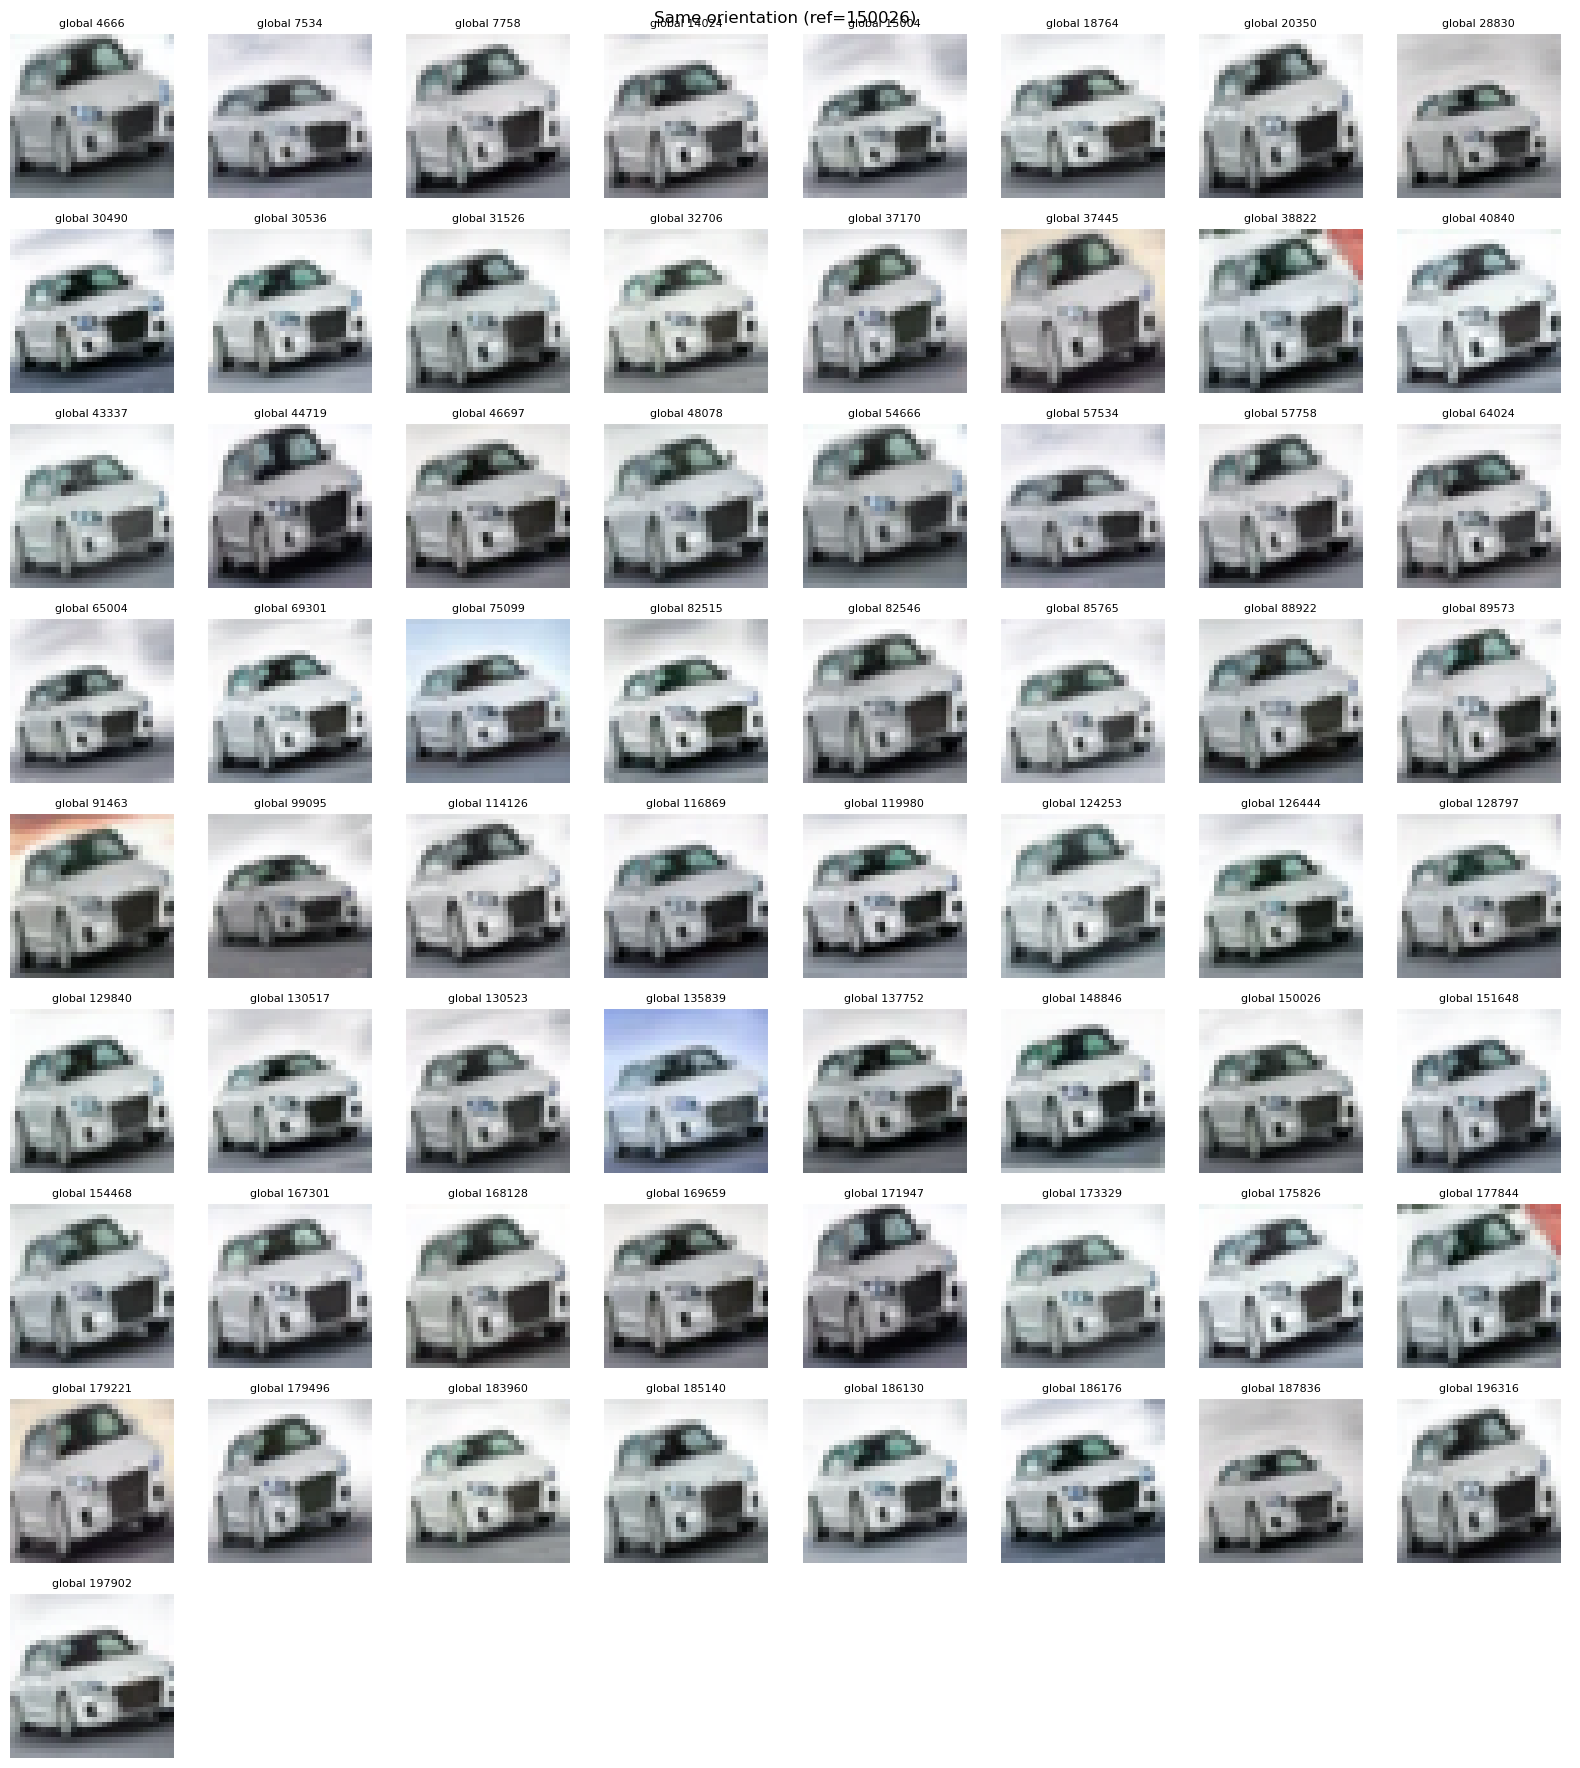

Same orientation (ref=150026)



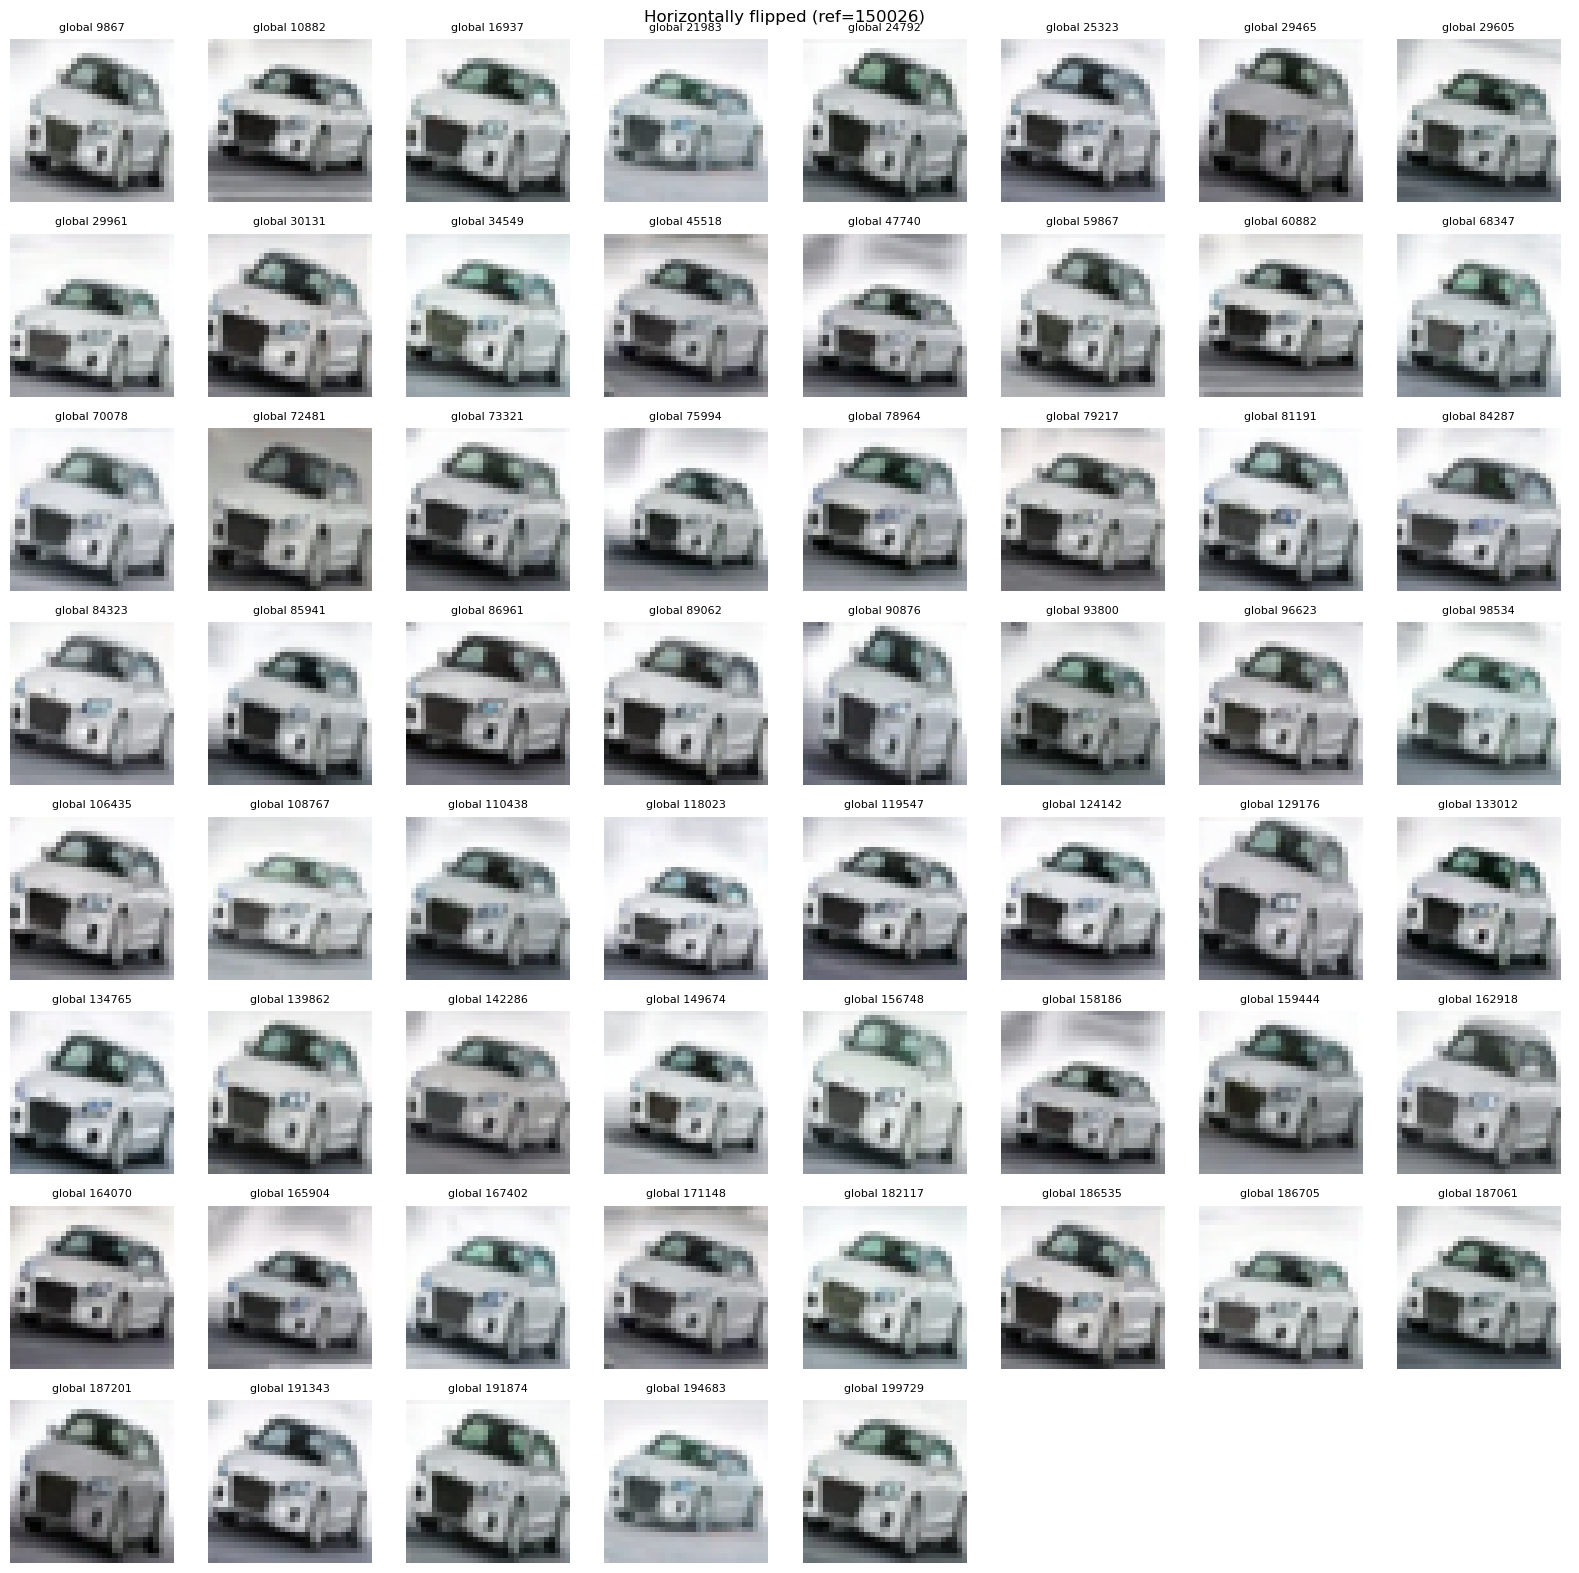

Horizontally flipped (ref=150026)

If any are misclassified, you can move them between groups.
Use local indices shown in brackets [k] in the printout above.
Input examples: '0 3 5' or just press Enter if none.


Indices to move from SAME -> FLIP (local indices in same group):  
Indices to move from FLIP -> SAME (local indices in flipped group):  


Current grouping: same=65, flipped=61


Are you satisfied with this grouping? [y/N]:  


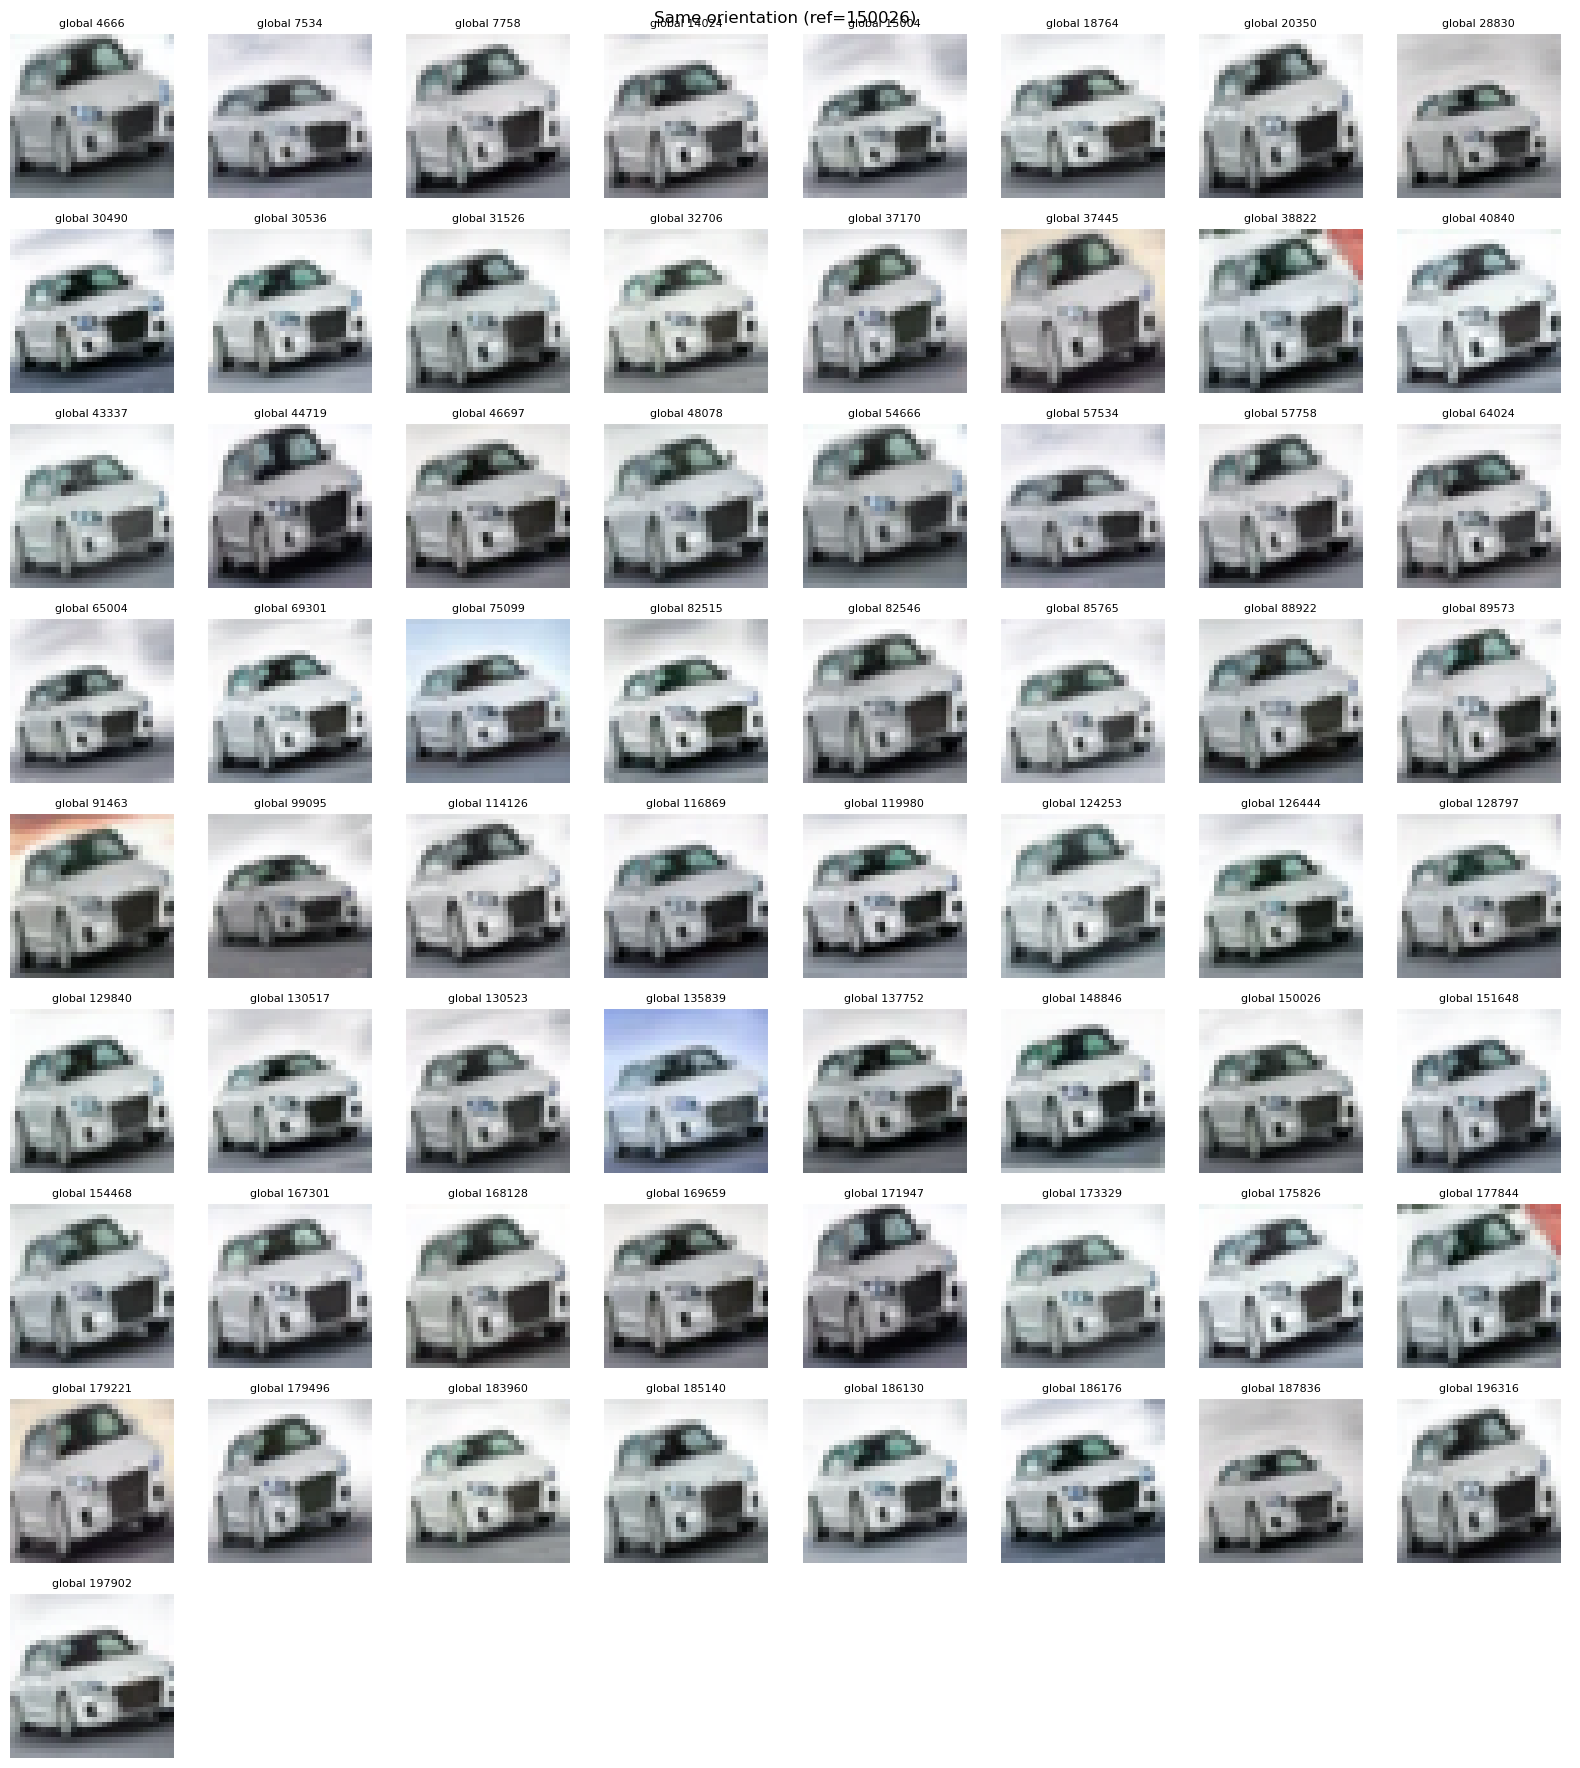

Same orientation (ref=150026)



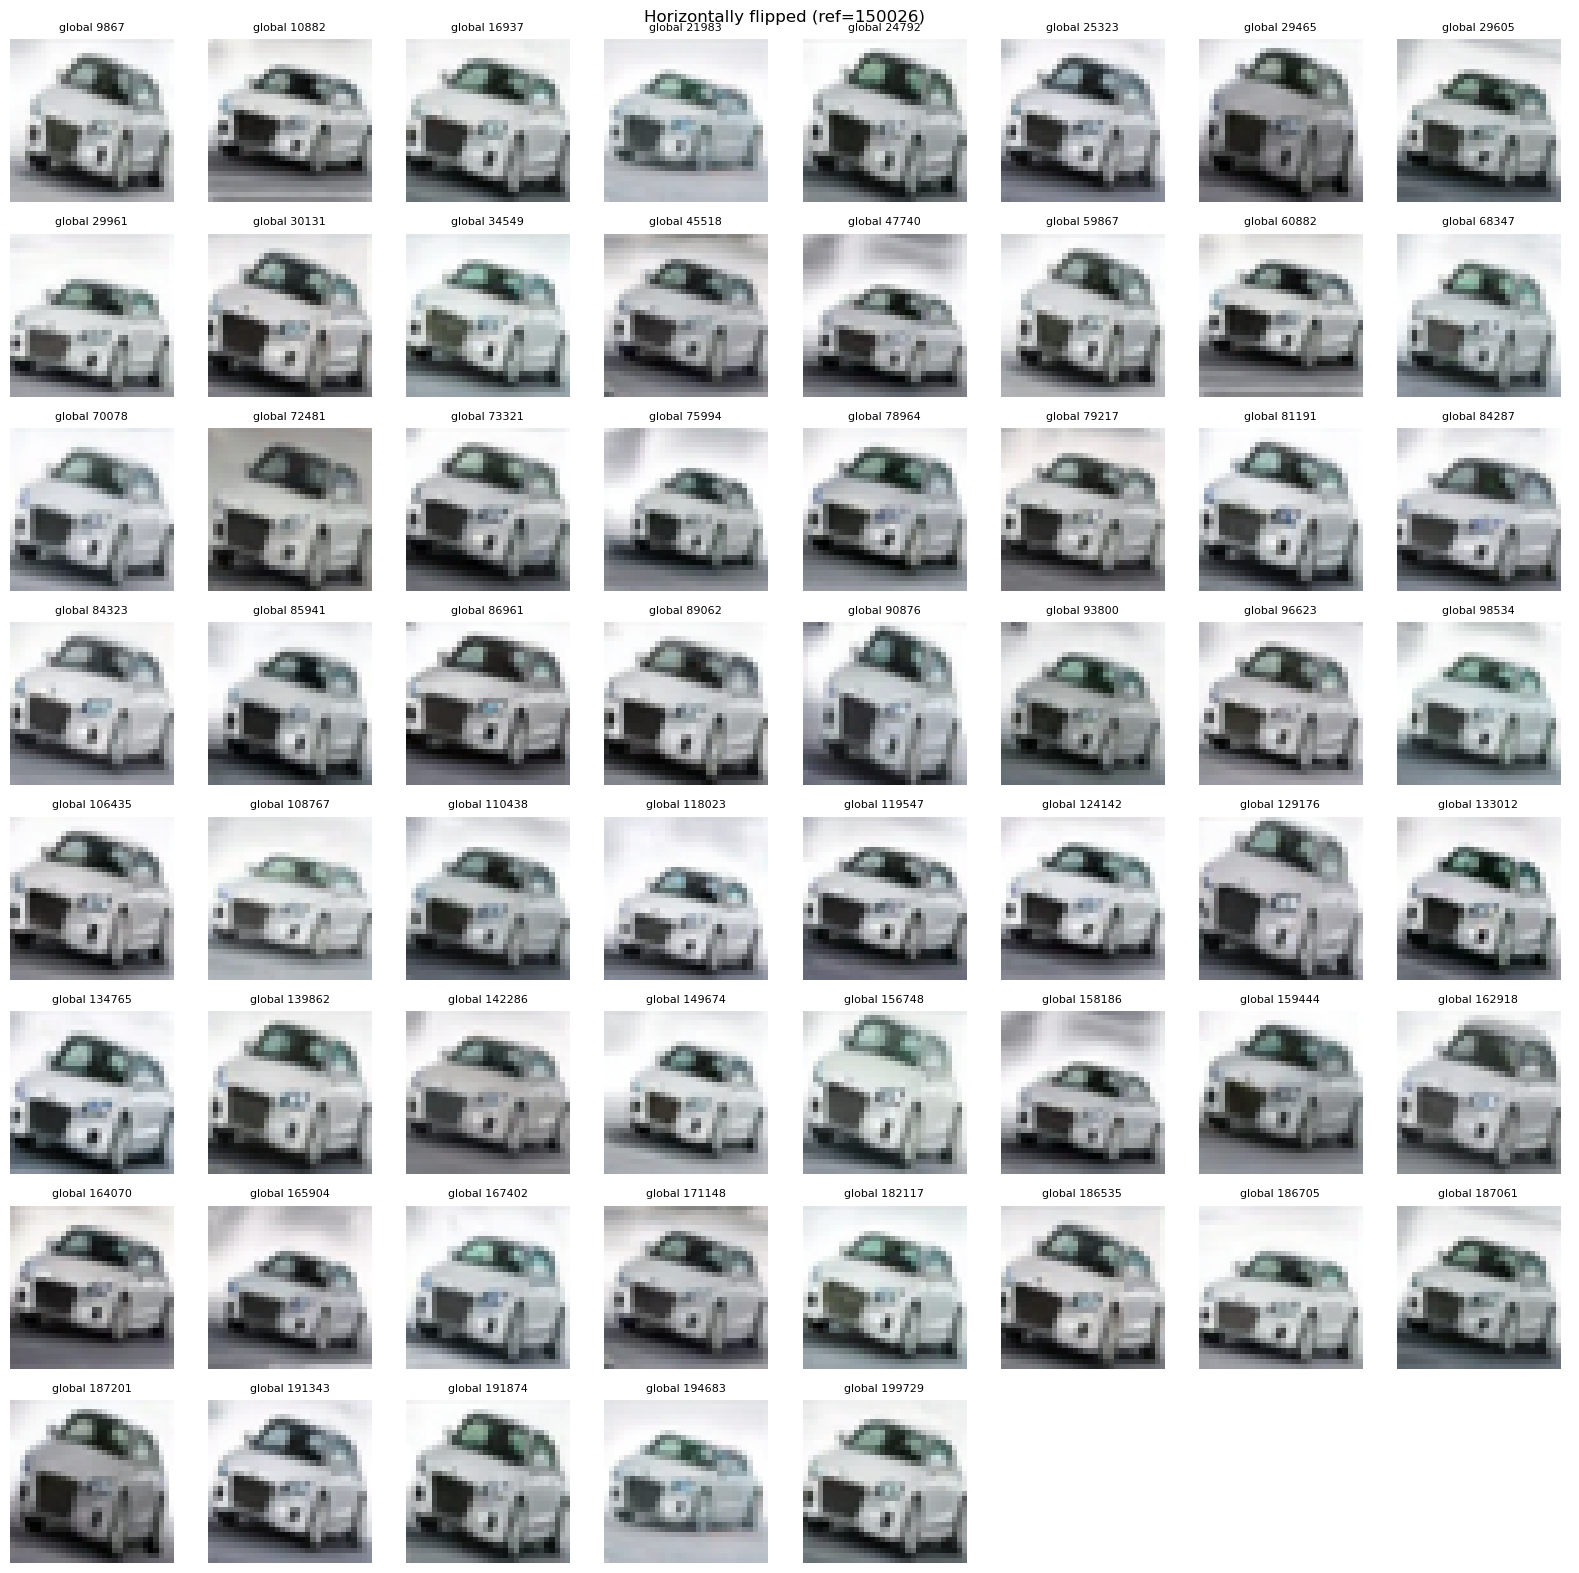

Horizontally flipped (ref=150026)

If any are misclassified, you can move them between groups.
Use local indices shown in brackets [k] in the printout above.
Input examples: '0 3 5' or just press Enter if none.


Indices to move from SAME -> FLIP (local indices in same group):  
Indices to move from FLIP -> SAME (local indices in flipped group):  


Current grouping: same=65, flipped=61


Are you satisfied with this grouping? [y/N]:  


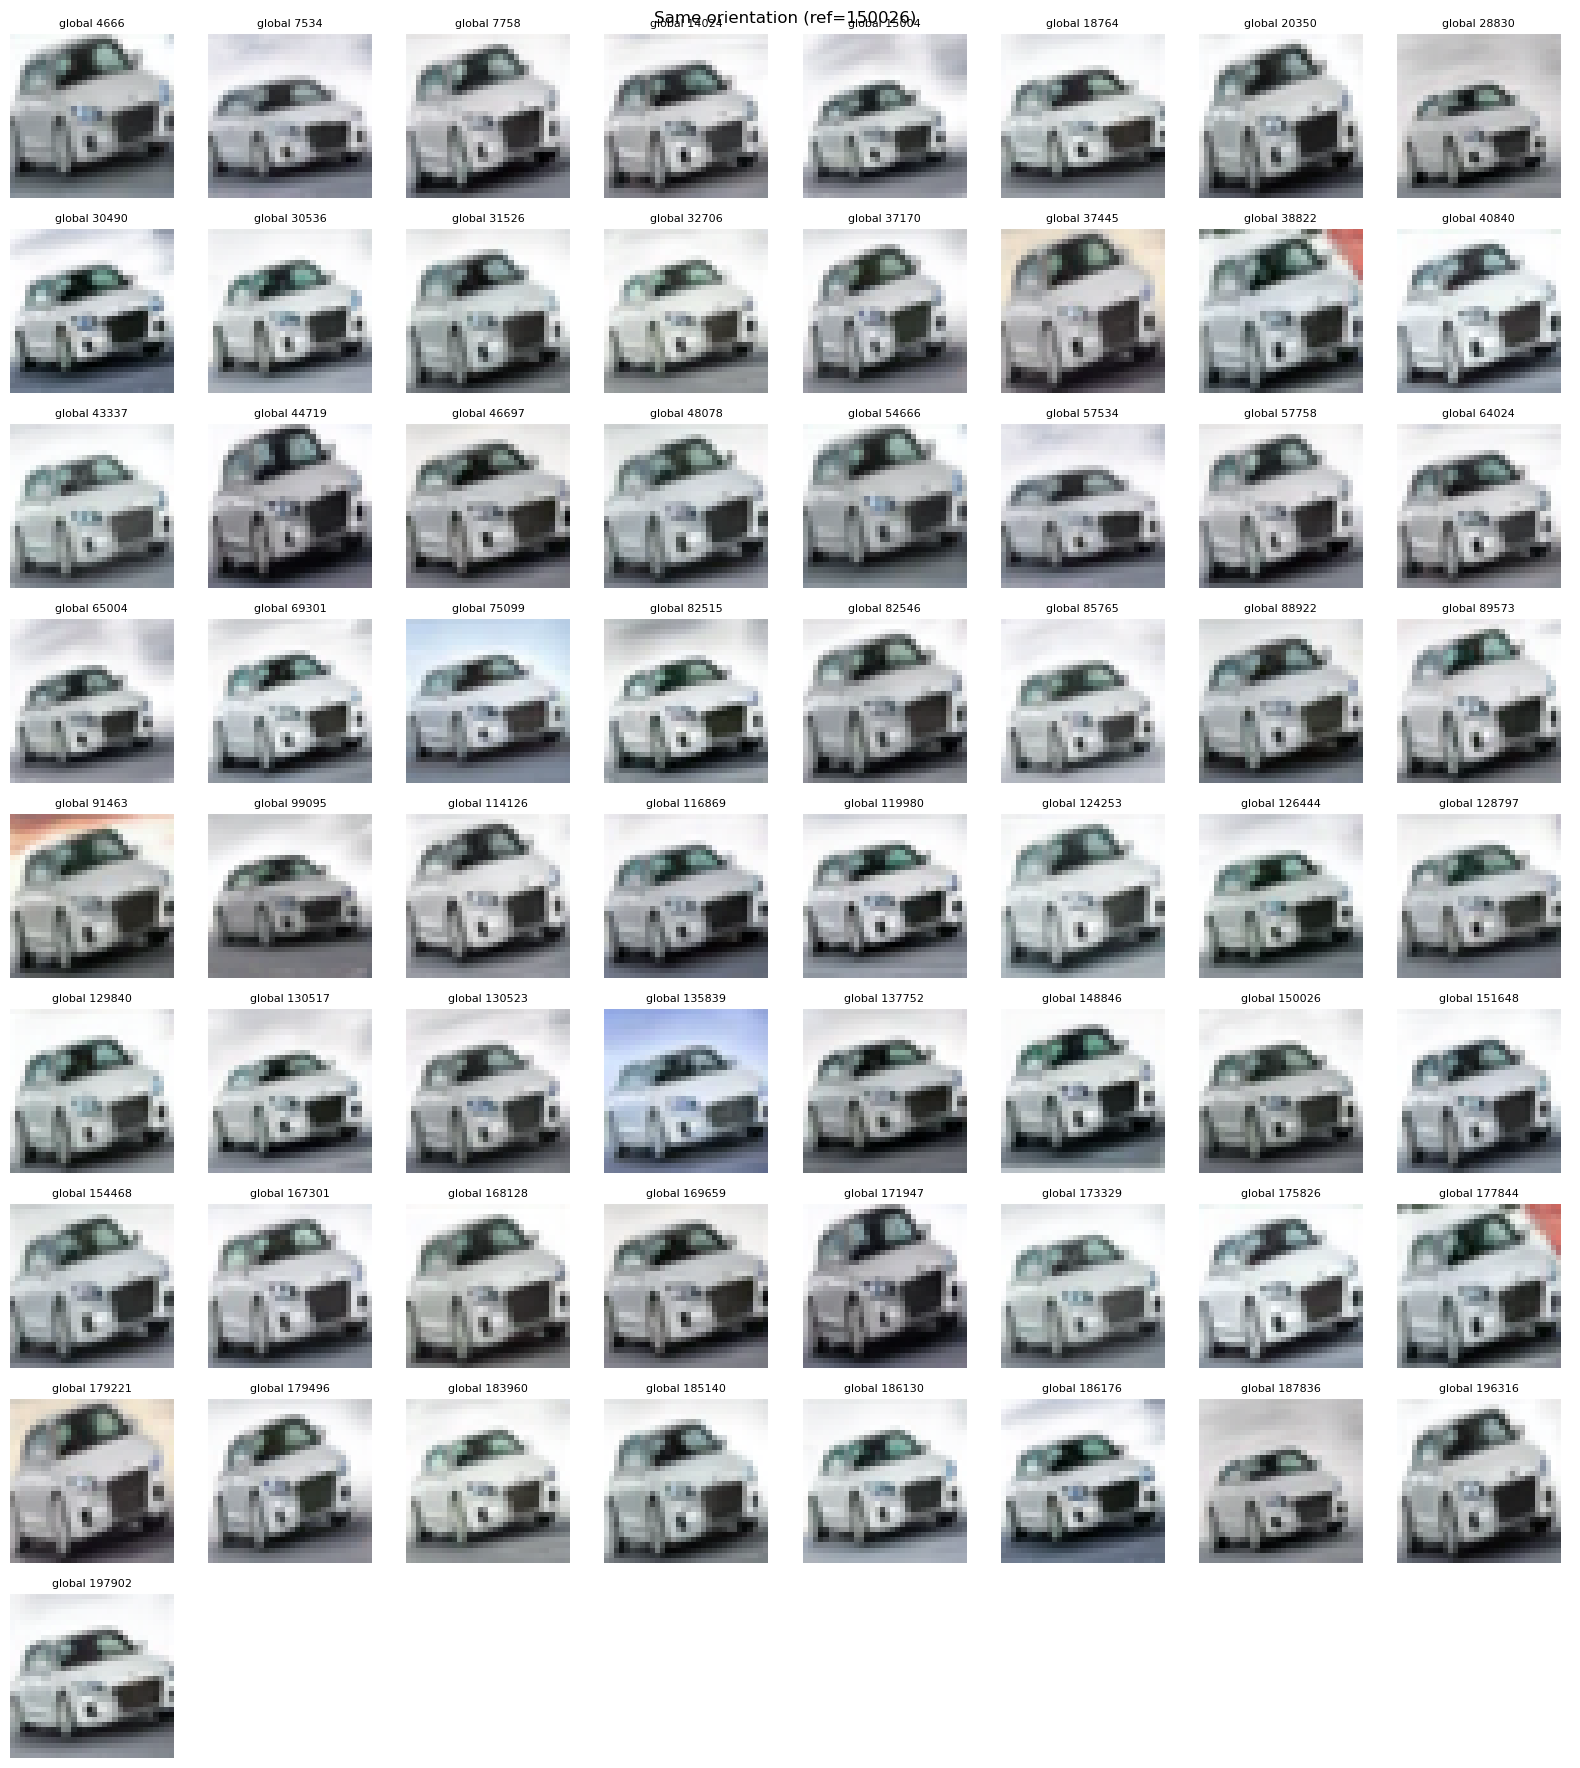

Same orientation (ref=150026)



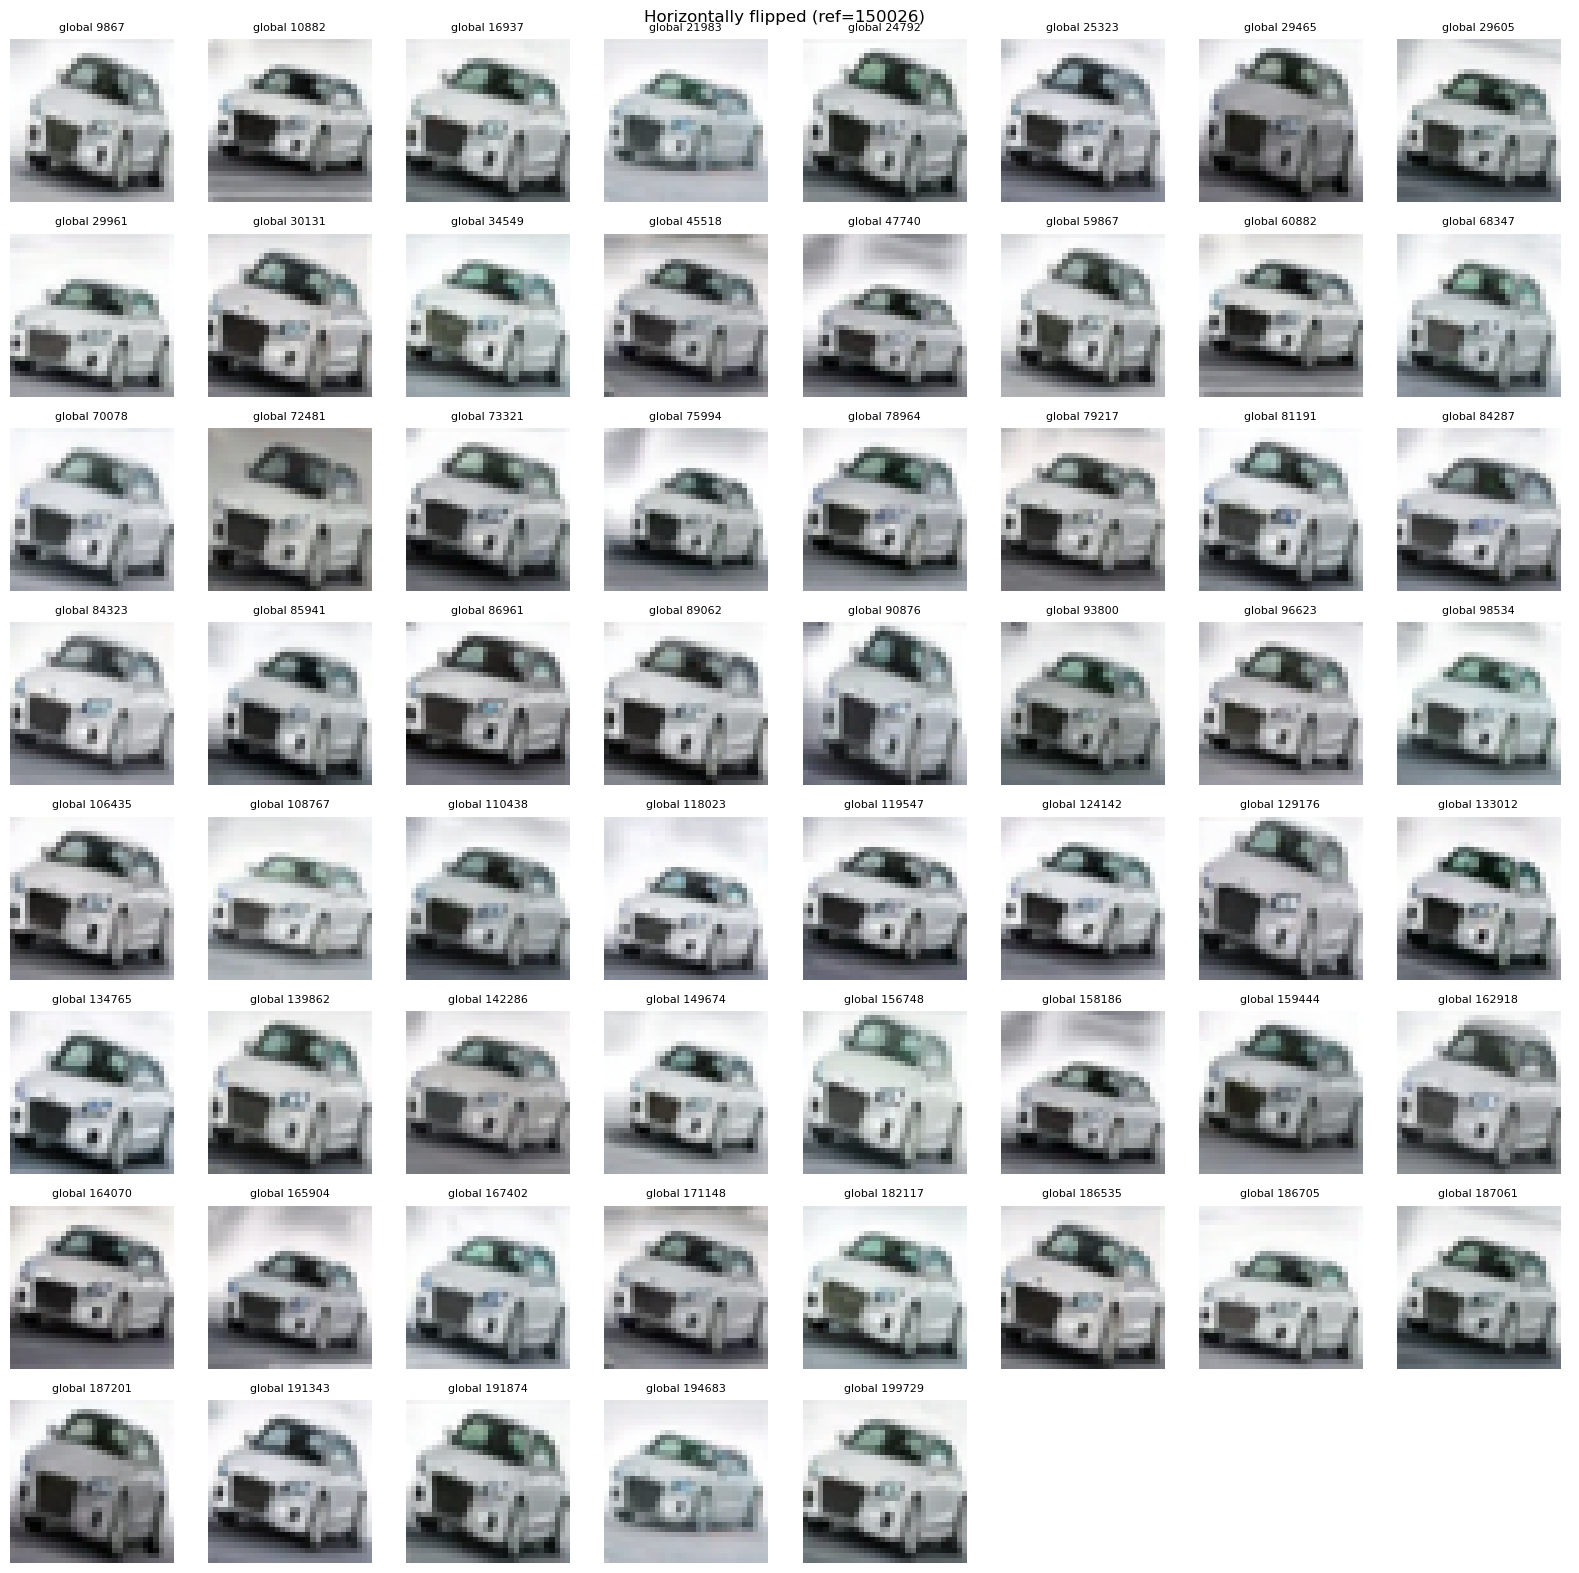

Horizontally flipped (ref=150026)

If any are misclassified, you can move them between groups.
Use local indices shown in brackets [k] in the printout above.
Input examples: '0 3 5' or just press Enter if none.


Indices to move from SAME -> FLIP (local indices in same group):  
Indices to move from FLIP -> SAME (local indices in flipped group):  


Current grouping: same=65, flipped=61


Are you satisfied with this grouping? [y/N]:  y


Saved images to /root/workspace/Python/flipd/notebooks/figs/DDPM_CIFAR/ref_150026
Zipped result to /root/workspace/Python/flipd/notebooks/figs/DDPM_CIFAR/ref_150026.zip


In [23]:
same_idx, flip_idx = inspect_symmetry_cluster(
    ref_idx=ref_idx,
    tau_sscd=tau_sscd,
    emb_gen=emb_gen,
    imgs_ddpm=imgs_ddpm,
    max_cols=8,
    save_dir=PATH_FIG,
)
mem_idx = same_idx + flip_idx

## Compute Complexity

In [27]:
if False:
    png_complexity = compute_png_complexity(imgs_ddpm)  # [N]
    np.save("ddpm_png_complexity.npy", png_complexity)
else:
    png_complexity = np.load("ddpm_png_complexity.npy")


In [28]:
import numpy as np
import torch
from tqdm import tqdm
from PIL import Image
import io

def compute_png_complexity(imgs: torch.Tensor) -> np.ndarray:
    """
    Complexity measure based on PNG compressed size.

    Args:
        imgs: [N, C, H, W] tensor in [0,1]

    Returns:
        complexity_bits: np.ndarray [N], PNG size in bits
    """
    imgs = imgs.detach().cpu()
    N = imgs.size(0)
    complexity_bits = np.empty(N, dtype=np.int32)

    for i in tqdm(range(N), desc="Computing PNG complexity"):
        img = imgs[i].clamp(0, 1)                   # [C,H,W]
        # to uint8 H×W×C
        img_np = (img.permute(1, 2, 0).numpy() * 255).astype("uint8")
        pil = Image.fromarray(img_np)

        buf = io.BytesIO()
        # `optimize=True` to make size more meaningful
        pil.save(buf, format="PNG", optimize=True)
        size_bytes = len(buf.getvalue())
        complexity_bits[i] = size_bytes * 8         # bits (scale doesn't matter, but you asked for bit-length)

    return complexity_bits


In [29]:
def select_far_sscd_similar_complexity_png(
    ref_idx: int,
    emb_gen,                  # [N,D] torch.Tensor or np.ndarray
    png_complexity: np.ndarray,  # [N], bit-lengths
    tau_sscd_min: float,      # lower bound on SSCD distance
    comp_tol: float,          # allowed abs diff in complexity (same units as png_complexity)
    max_count: int | None = None,
    rng_seed: int = 42,
):
    """
    Select indices i such that:
      1) SSCD distance(ref, i) > tau_sscd_min
      2) |PNG_complexity(i) - PNG_complexity(ref)| <= comp_tol

    If max_count is not None and there are too many candidates, we draw
    a subset of size max_count by *importance sampling*:

        p(i) ∝ exp( -0.5 * ((complexity(i) - complexity(ref)) / sigma)^2 )

    where sigma is tied to comp_tol. This keeps the mean complexity of
    selected indices close to the reference (in expectation) but still
    leaves a non-trivial spread, suitable for KDE plots.

    Args:
        ref_idx       : int, reference index in [0,N)
        emb_gen       : [N,D] embeddings
        png_complexity: [N] bit-lengths for each image
        tau_sscd_min  : float, lower bound on SSCD distance (far from ref)
        comp_tol      : float, allowed abs difference in complexity
        max_count     : optional, cap on number of returned indices
        rng_seed      : random seed for subsampling

    Returns:
        selected_idx : np.ndarray of indices
        dist_ref_sel : np.ndarray, SSCD distances ref→i for selected
        comp_diff_sel: np.ndarray, |complexity(i) - complexity(ref)| for selected
    """
    # ---- embeddings to numpy ----
    if isinstance(emb_gen, torch.Tensor):
        emb = emb_gen.detach().cpu().numpy()
    else:
        emb = np.asarray(emb_gen)
    N = emb.shape[0]

    png_complexity = np.asarray(png_complexity)
    assert png_complexity.shape[0] == N

    # ---- SSCD distance to ref ----
    ref_emb = emb[ref_idx]
    diff = emb - ref_emb[None, :]
    dist = np.linalg.norm(diff, axis=1)            # [N]

    # ---- complexity diffs ----
    comp_ref = png_complexity[ref_idx]
    comp_diff = np.abs(png_complexity - comp_ref)  # [N]

    # ---- masks ----
    mask_far = dist > tau_sscd_min
    mask_far[ref_idx] = False

    mask_comp = comp_diff <= comp_tol
    mask = mask_far & mask_comp

    selected_idx = np.where(mask)[0]

    # If no candidates, just return empty
    if selected_idx.size == 0:
        return selected_idx, dist[selected_idx], comp_diff[selected_idx]

    # optional subsampling: importance sampling around comp_ref (not deterministic window)
    if max_count is not None and len(selected_idx) > max_count:
        cand_idx = selected_idx
        cand_comp = png_complexity[cand_idx]

        # deviations from reference complexity
        delta = cand_comp - comp_ref

        # choose sigma tied to tolerance: broad but centered
        # e.g. sigma = comp_tol / 2 (fallback if comp_tol==0)
        sigma = comp_tol / 2.0 if comp_tol > 0 else (np.std(delta) + 1e-8)

        # Gaussian-like weights around comp_ref
        w = np.exp(-0.5 * (delta / (sigma + 1e-12)) ** 2)

        # in case comp_tol is tiny, ensure non-degenerate weights
        if not np.isfinite(w).all() or np.all(w == 0):
            w = np.ones_like(w, dtype=float)

        w = w / w.sum()

        rng = np.random.default_rng(rng_seed)
        chosen = rng.choice(cand_idx, size=max_count, replace=False, p=w)

        selected_idx = np.sort(chosen)  # sort for reproducibility / debugging

    dist_ref_sel  = dist[selected_idx]
    comp_diff_sel = comp_diff[selected_idx]

    return selected_idx, dist_ref_sel, comp_diff_sel


In [30]:
png_complexity = np.load("ddpm_png_complexity.npy")

tau_sscd_min = 0.30        # "far" in SSCD (tune)
comp_tol = 1000.0           # bits difference you allow (tune; 200 bits ~ 25 bytes)
max_count = 200            # optional

selected_idx, dist_ref, comp_diff = select_far_sscd_similar_complexity_png(
    ref_idx=ref_idx,
    emb_gen=emb_gen,
    png_complexity=png_complexity,
    tau_sscd_min=tau_sscd_min,
    comp_tol=comp_tol,
    max_count=max_count,
)

print("Selected:", len(selected_idx))
print("SSCD distances:", dist_ref.min(), "–", dist_ref.max())
print("PNG |Δbits|:", comp_diff.min(), "–", comp_diff.max())

Selected: 200
SSCD distances: 1.152308 – 1.3777219
PNG |Δbits|: 0 – 992


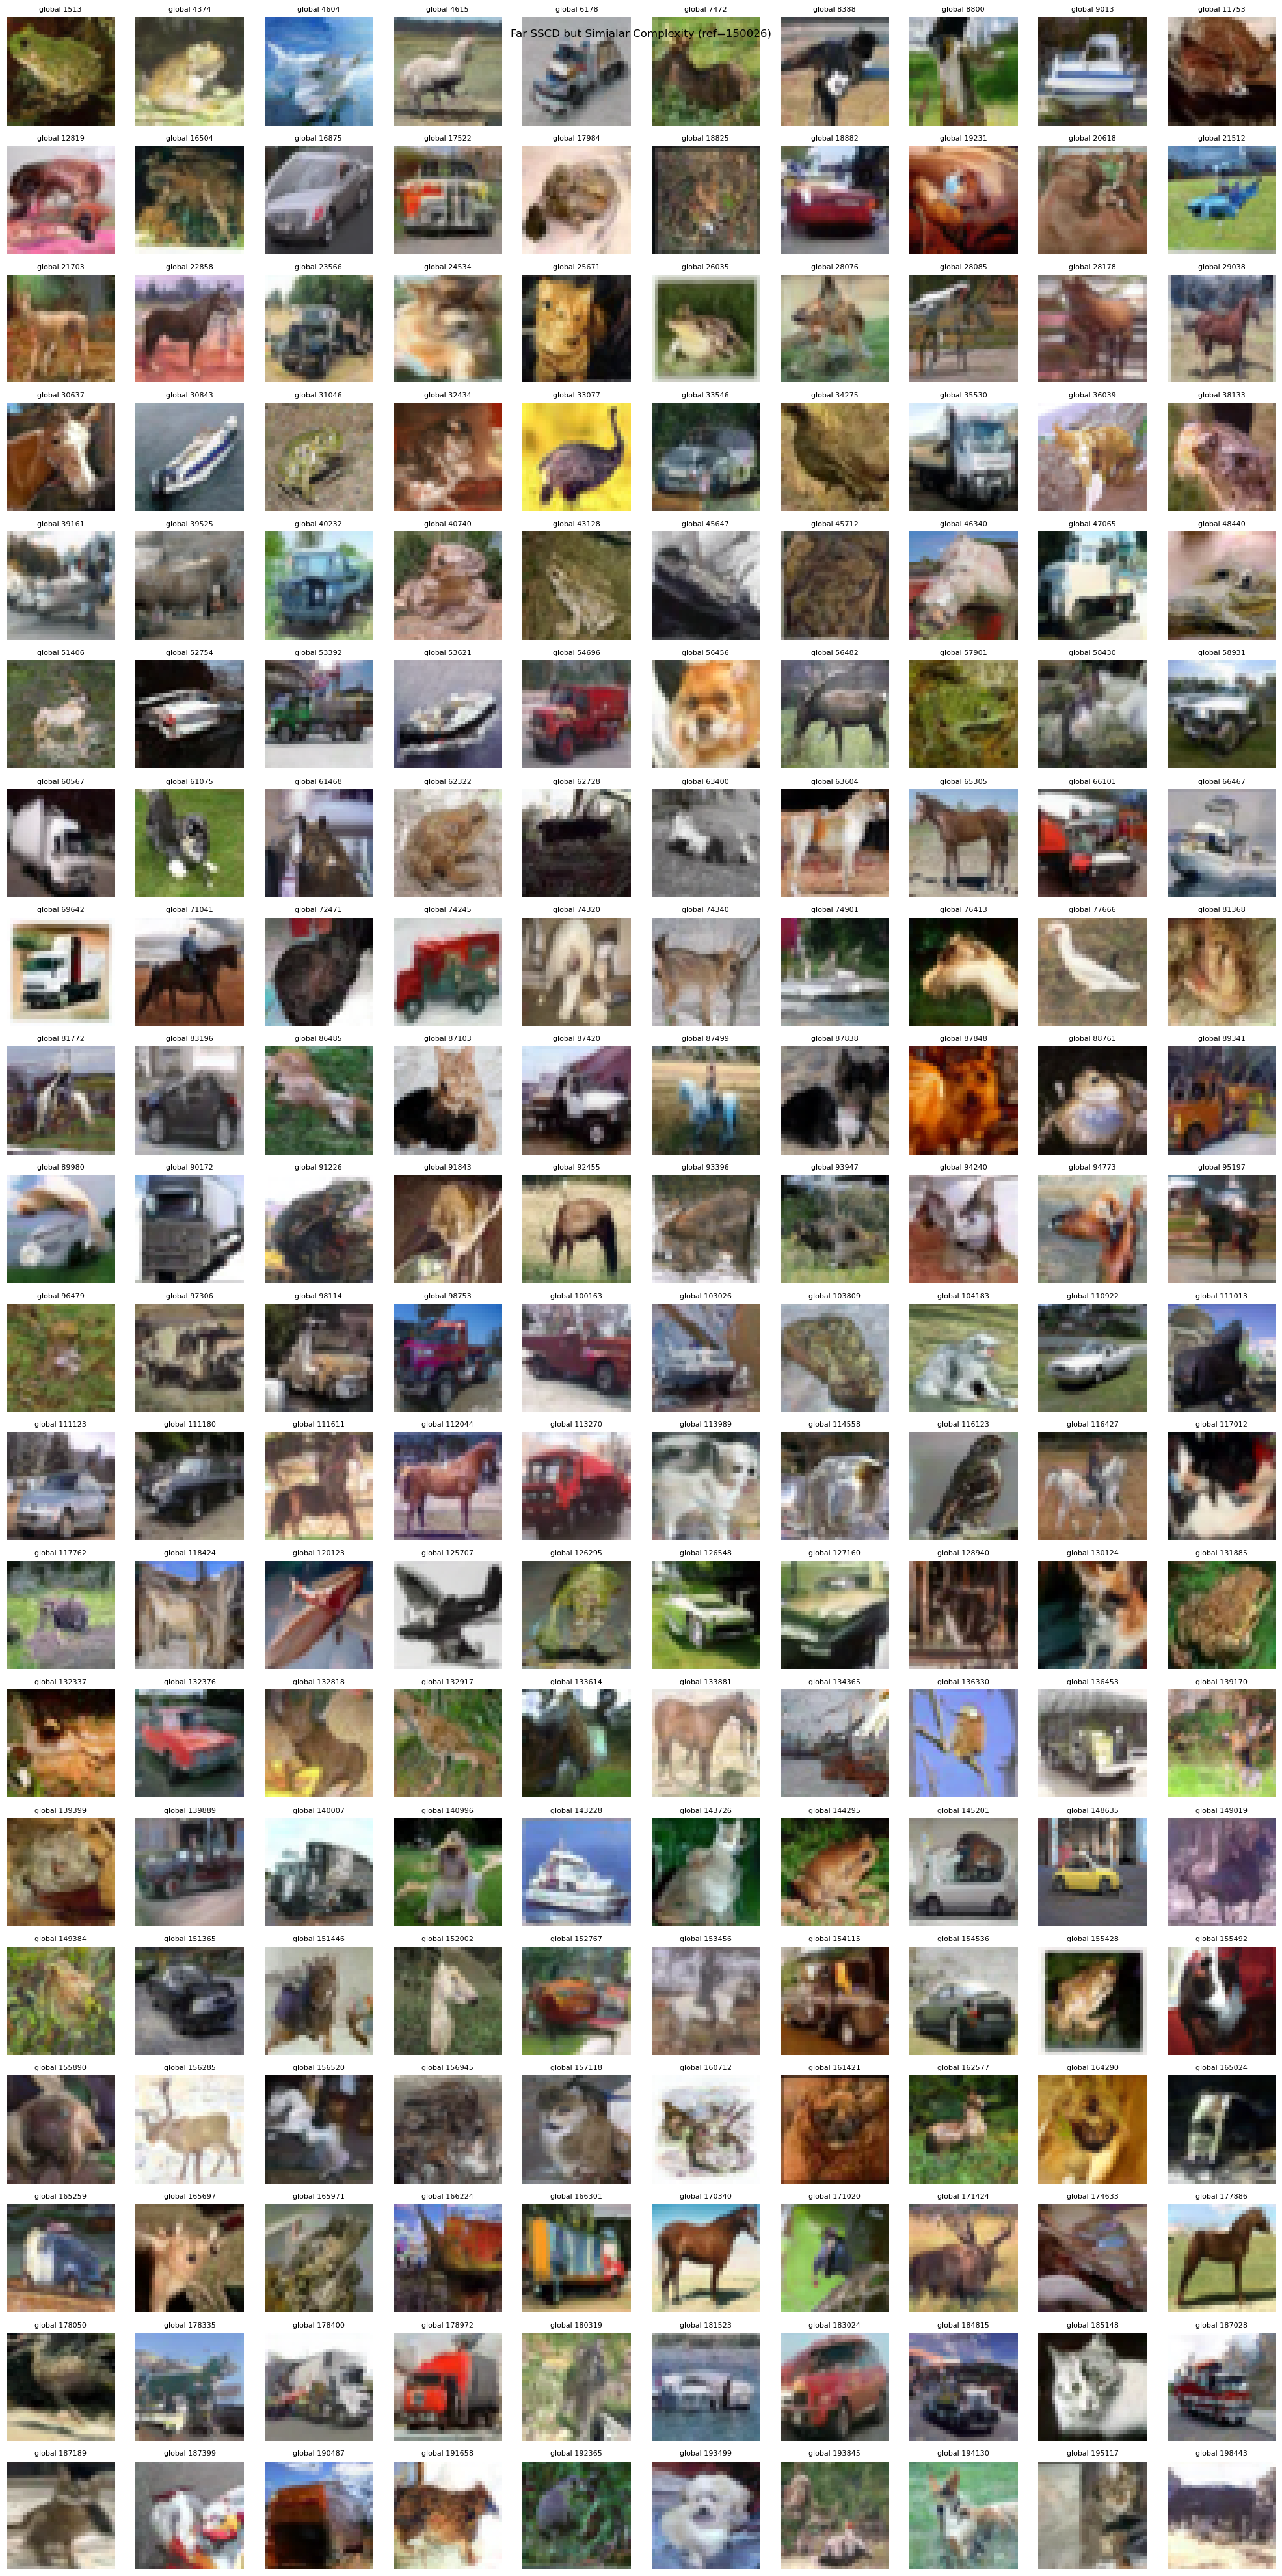

Far SSCD but Simialar Complexity (ref=150026)



In [32]:
show_image_grid(imgs_ddpm, selected_idx, title=f"Far SSCD but Simialar Complexity (ref={ref_idx})", max_cols=10)

save_dir = Path(PATH_FIG)
sim_dir =  save_dir / f"ref_{ref_idx}" / "sim_comp"

for idx in selected_idx:
    save_tensor_as_png(
        imgs_ddpm[idx],
        sim_dir / f"idx_{idx}.png"
    )

Loading pipeline components...:   0%|          | 0/6 [00:00<?, ?it/s]

You have disabled the safety checker for <class 'diffusers.pipelines.stable_diffusion.pipeline_stable_diffusion.StableDiffusionPipeline'> by passing `safety_checker=None`. Ensure that you abide to the conditions of the Stable Diffusion license and do not expose unfiltered results in services or applications open to the public. Both the diffusers team and Hugging Face strongly recommend to keep the safety filter enabled in all public facing circumstances, disabling it only for use-cases that involve analyzing network behavior or auditing its results. For more information, please have a look at https://github.com/huggingface/diffusers/pull/254 .


126
200
... saved /root/workspace/Python/flipd/notebooks/figs/DDPM_CIFAR/fig_DDPM_CIFAR_MEM_comp_refidx_150026.png


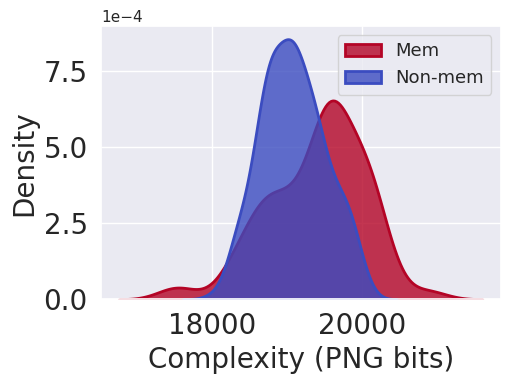

In [33]:
import visualization.notebook_utils as notebook_utils
importlib.reload(notebook_utils)
from visualization.notebook_utils import plot_histograms, plot_kde

print(len(mem_idx))
print(len(selected_idx))

#cm = plt.cm.cividis
#colors = [cm(0.95), cm(0.0)]

cm = plt.cm.coolwarm
colors = ["crimson", "darkblue"]
colors = [cm(1.0), "darkblue"]
colors = [cm(1.0), cm(0.0)]



    
filename_kde = os.path.join(PATH_FIG, f"fig_DDPM_CIFAR_MEM_comp_refidx_{ref_idx}")
plot_kde(
    png_complexity[mem_idx],
    png_complexity[selected_idx],
    labels=["Mem", "Non-mem"],
    _x_label="Complexity (PNG bits)",
    filename=filename_kde,
    colors=colors
)

## Clean up memory

In [34]:
import gc, torch, contextlib
def free_cuda(*objs):
    # drop strong refs
    for o in objs:
        try:
            del o
        except:
            pass
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
        torch.cuda.ipc_collect()  # helpful in notebooks
        print("GPU freed.",
              "alloc=", round(torch.cuda.memory_allocated()/1e6,1), "MB,",
              "reserved=", round(torch.cuda.memory_reserved()/1e6,1), "MB")
free_cuda(vp_sde, lid_soft_dof, lid_estimator_soft_dof, x_flat, x_ddpm)  # anything large

NameError: name 'vp_sde' is not defined

In [ ]:
import gc, torch
gc.collect()
torch.cuda.empty_cache()
del lid_estimator_soft_dof



### Train VP SDE

In [35]:
import torch
import torch.nn as nn

class DDPMPixelAdapter(nn.Module):
    """
    Wraps a diffusers UNet2DModel so that:
      - input x is [B, D] flat
      - timestep t is a scalar or [B] tensor of integers
      - output is sigma_t * score(x,t) = -eps, flattened to [B, D]
    """
    def __init__(self, unet, img_channels=3, img_size=32, num_train_timesteps=1000):
        super().__init__()
        self.unet = unet
        self.C = img_channels
        self.H = img_size
        self.W = img_size
        self.D = img_channels * img_size * img_size
        self.num_train_timesteps = num_train_timesteps

    def forward(self, x, t, **kwargs):
        """
        x: [B, D] flattened image
        t: [B] or scalar, in the index space expected by ddpm.unet
        returns: [B, D]  = sigma_t * score(x,t) = -eps
        """
        B = x.shape[0]
        assert x.shape[1] == self.D, f"Expected dim {self.D}, got {x.shape[1]}"

        # reshape to image
        x_img = x.view(B, self.C, self.H, self.W)

        # make sure t is a 1D tensor of length B, on same device
        if not torch.is_tensor(t):
            t = torch.tensor([t], device=x.device)
        if t.ndim == 0:
            t = t.expand(B)
        else:
            t = t.to(x.device)
        t = t.long()

        # UNet predicts eps
        out = self.unet(sample=x_img, timestep=t, **kwargs)
        eps = out.sample                      # [B, C, H, W]

        # For VP: sigma_t * score = -eps
        return (-eps).view(B, self.D)


In [36]:
from models.diffusions.sdes import VpSde
# #from lid.diffusions import local_hessian_spectrum as lhs
# from lid.diffusions.local_hessian_spectrum import (
#     LocalHessianSpectralEstimator, VPSchedule
# )
# importlib.reload(lhs)
from notebooks.lid.base import LIDEstimator
from notebooks.lid.diffusions.local_hessian_spectrum import LocalHessianSpectralEstimator, VPSchedule
from notebooks.lid.diffusions.local_hessian_spectrum import LHSEArtifact

ddpm.unet.eval()
ddpm.unet = ddpm.unet.to(device).float()

ddpm_adapter = DDPMPixelAdapter(
    unet=ddpm.unet,
    img_channels=3,
    img_size=32,
)
vp_sde = VpSde(
    score_net=ddpm_adapter,
)
lid_estimator_soft_dof = LocalHessianSpectralEstimator(
    model=vp_sde,
    schedule=VPSchedule(beta_min=0.1, beta_max=20.0),
    method="Soft_DoF",
    ambient_dim=32*32*3,
    device=device,
    batch_size=8,
    soft_c=0.7,
    soft_p=8,
)

In [37]:
import numpy as np
import torch
from tqdm import tqdm

def estimate_lid_for_indices(
    imgs_all: torch.Tensor,
    indices,
    lid_estimator,
    delta: float,
    device,
    batch_size: int = 8,
    arg_name: str = "delta",
    **extra_kwargs,
):
    """
    Compute LID for a subset of generated images.

    Args:
        imgs_all     : [N,C,H,W] tensor (e.g. imgs_ddpm)
        indices      : list/array of global indices into imgs_all
        lid_estimator: e.g. lid_estimator_soft_dof, NB estimator, etc.
        delta        : scale parameter (e.g. delta, noise_time, t, ...)
        device       : torch.device
        batch_size   : mini-batch size
        arg_name     : name of the keyword for the scale parameter in
                       lid_estimator.estimate_lid (e.g. "delta", "noise_time", "t")
        extra_kwargs : any other keyword arguments to pass to estimate_lid

    Returns:
        lids: np.ndarray [len(indices)]
    """
    idx = np.asarray(indices, dtype=int)
    N = len(idx)
    lids = np.empty(N, dtype=np.float32)

    for start in tqdm(range(0, N, batch_size), desc="Estimating LID (subset)"):
        end = min(start + batch_size, N)
        batch_idx = idx[start:end]

        x = imgs_all[batch_idx].to(device)      # [B,C,H,W]
        B = x.size(0)
        x_flat = x.view(B, -1)                  # [B, D]
        x_flat.requires_grad_(True)

        # Build kwargs like {"delta": delta} or {"noise_time": delta} etc.
        lid_kwargs = {arg_name: delta}
        lid_kwargs.update(extra_kwargs)

        lid_batch = lid_estimator.estimate_lid(
            x_flat,
            **lid_kwargs,
        )  # [B]

        lids[start:end] = lid_batch.detach().cpu().numpy()

    return lids



In [43]:
from sklearn.metrics import roc_auc_score
from sklearn.metrics import average_precision_score

def compute_auroc(lid_mem, lid_nonmem):
    y_true = np.array([0]*len(lid_mem) + [1]*len(lid_nonmem))  # 1=positive, 0=negative
    y_score = np.concatenate((lid_mem, lid_nonmem))
    auroc = roc_auc_score(y_true, y_score)
    return auroc

def compute_aupr(lid_mem, lid_nonmem):
    y_true = np.array([0]*len(lid_mem) + [1]*len(lid_nonmem))
    y_score = np.concatenate((lid_mem, lid_nonmem))
    aupr = average_precision_score(y_true, y_score)
    return aupr

In [39]:
delta = 0.01 # or whatever worked well for you
mem_idx = same_idx + flip_idx

lid_mem = estimate_lid_for_indices(
    imgs_all=imgs_ddpm,
    indices=mem_idx,
    lid_estimator=lid_estimator_soft_dof,
    delta=delta,
    device=device,
    batch_size=8,
)

lid_nonmem = estimate_lid_for_indices(
    imgs_all=imgs_ddpm,
    indices=selected_idx[:len(lid_mem)],
    lid_estimator=lid_estimator_soft_dof,
    delta=delta,
    device=device,
    batch_size=8,
)

print("memorized LID:", lid_mem.shape, np.mean(lid_mem))
print("non memorized LID:", lid_nonmem.shape, np.mean(lid_nonmem))


Estimating LID (subset): 100%|██████████| 16/16 [00:25<00:00,  1.60s/it]

memorized LID: (126,) 472.8615
non memorized LID: (126,) 882.0711


... saved /root/workspace/Python/flipd/notebooks/figs/DDPM_CIFAR/fig_DDPM_CIFAR_MEM_LHS_refidx_150026.png


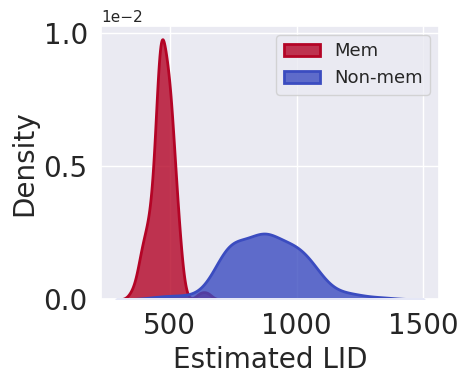

AUROC: 0.9930083144368859
AUPR: 0.9955041402814059


In [44]:
import matplotlib.pyplot as plt
import seaborn as sns
import visualization.notebook_utils as notebook_utils
importlib.reload(notebook_utils)
from visualization.notebook_utils import plot_histograms, plot_kde

# filename_hist = os.path.join(PATH_FIG, f"fig_hist_CIFAR_controled_refidx_{ref_idx}")
# plot_histograms(lid_mem, lid_nonmem, labels=['Memorized', 'Non-memorized'], filename=filename_hist)

# cividis = plt.cm.cividis
# colors = [cividis(0.95), cividis(0.0)]
cividis = plt.cm.coolwarm
colors = [cm(1.0), "darkblue"]
colors = ["crimson", "darkblue"]
colors = [cm(1.0), cm(0.0)]


plot_kde(
    lid_mem,
    lid_nonmem,
    labels=["Mem", "Non-mem", ],
    #colors=["darkgreen", "orange"],
    filename=os.path.join(PATH_FIG, f"fig_DDPM_CIFAR_MEM_LHS_refidx_{ref_idx}"),
    colors=colors,
)
print('AUROC:', compute_auroc(lid_mem, lid_nonmem))
print('AUPR:',  compute_aupr( lid_mem, lid_nonmem))

## NB

In [ ]:
from lid.diffusions import NormalBundleEstimator
lid_estimator_nb = NormalBundleEstimator(model=vp_sde, ambient_dim=32*32*3, device=device,)
delta = 0.001
lid_nb_mem = estimate_lid_for_indices(
    imgs_all=imgs_ddpm,
    indices=mem_idx,
    lid_estimator=lid_estimator_nb,
    delta=delta,
    device=device,
    batch_size=80,
    arg_name="noise_time",
)

lid_nb_nonmem = estimate_lid_for_indices(
    imgs_all=imgs_ddpm,
    indices=selected_idx[:len(lid_nb_mem)],
    lid_estimator=lid_estimator_nb,
    delta=delta,
    device=device,
    batch_size=80,
    arg_name="noise_time",
)

print("memorized LID:", lid_nb_mem.shape, np.mean(lid_nb_mem))
print("non memorized LID:", lid_nb_nonmem.shape, np.mean(lid_nb_nonmem))

In [ ]:
plot_kde(
    lid_nb_mem,
    lid_nb_nonmem,
    labels=["Mem", "Non-mem", ],
    #colors=["darkgreen", "orange"],
    filename=os.path.join(PATH_FIG, f"fig_DDPM_CIFAR_MEM_NB_refidx_{ref_idx}")
)
print('AUROC:', compute_auroc(lid_nb_mem, lid_nb_nonmem))

## LIDL

In [45]:
from lid.diffusions.fokker_planck import FPRegressEstimator
delta = 0.01
lid_estimator_lidl = FPRegressEstimator(model=vp_sde, ambient_dim=32*32*3,device=device,)

lid_lidl_mem = estimate_lid_for_indices(
    imgs_all=imgs_ddpm,
    indices=mem_idx,
    lid_estimator=lid_estimator_lidl,
    delta=delta,
    device=device,
    batch_size=80,
    arg_name="delta",
)

lid_lidl_nonmem = estimate_lid_for_indices(
    imgs_all=imgs_ddpm,
    indices=selected_idx[:len(lid_lidl_mem)],
    lid_estimator=lid_estimator_lidl,
    delta=delta,
    device=device,
    batch_size=80,
    arg_name="delta",
)

print("memorized LID:", lid_lidl_mem.shape, np.mean(lid_lidl_mem))
print("non memorized LID:", lid_lidl_nonmem.shape, np.mean(lid_lidl_nonmem))

NameError: name 'vp_sde' is not defined

In [44]:
plot_kde(
    lid_lidl_mem,
    lid_lidl_nonmem,
    labels=["Mem", "Non-mem", ],
    #colors=["darkgreen", "orange"],
    filename=os.path.join(PATH_FIG, f"fig_DDPM_CIFAR_MEM_LIDL_refidx_{ref_idx}")
)
print('AUROC:', compute_auroc(lid_lidl_mem, lid_lidl_nonmem))

NameError: name 'lid_lidl_mem' is not defined

## FLIPD

In [ ]:
from lid.diffusions.fokker_planck import FlipdEstimator
delta = 0.01
lid_estimator_flipd = FlipdEstimator(model=vp_sde, ambient_dim=32*32*3, device=device,)

lid_flipd_mem = estimate_lid_for_indices(
    imgs_all=imgs_ddpm,
    indices=mem_idx,
    lid_estimator=lid_estimator_flipd,
    delta=delta,
    device=device,
    batch_size=80,
    arg_name="t",
)

lid_flipd_nonmem = estimate_lid_for_indices(
    imgs_all=imgs_ddpm,
    indices=selected_idx[:len(lid_flipd_mem)],
    lid_estimator=lid_estimator_flipd,
    delta=delta,
    device=device,
    batch_size=80,
    arg_name="t",
)

print("memorized LID:", lid_flipd_mem.shape, np.mean(lid_flipd_mem))
print("non memorized LID:", lid_flipd_nonmem.shape, np.mean(lid_flipd_nonmem))


In [ ]:
lid_flipd_mem = lid_flipd_mem_flipd
plot_kde(
    lid_flipd_mem,
    lid_flipd_nonmem,
    labels=["Mem", "Non-mem", ],
    #colors=["darkgreen", "orange"],
    filename=os.path.join(PATH_FIG, f"fig_DDPM_CIFAR_MEM_FLIPD_refidx_{ref_idx}")
)
print('AUROC:', compute_auroc(lid_flipd_mem, lid_flipd_nonmem))

## ESS

In [ ]:
from lid.skdim.skdim import SkdimLIDEstimator

flat_mem = imgs_ddpm[mem_idx].view(len(mem_idx), -1)
print(flat_mem.shape)

nonmem_idx = selected_idx[:len(mem_idx)]
flat_nonmem = imgs_ddpm[nonmem_idx].view(len(nonmem_idx), -1)
print(flat_nonmem.shape)

_flat = torch.cat([flat_mem, flat_nonmem], dim=0)
print(_flat.shape)

est = SkdimLIDEstimator(data=imgs_cifar[:500], ambient_dim=32*32*3, estimator_type="ESS")
#est.fit(n_neighbors=1, n_jobs=-1)
est.fit()
lid_ess = est.estimate_lid(_flat).detach().cpu().numpy()

lid_ess_mem = lid_ess[:len(mem_idx)]
lid_ess_nonmem = lid_ess[len(nonmem_idx):]


print("memorized LID:", lid_ess_mem.shape, np.mean(lid_ess_mem))
print("non memorized LID:", lid_ess_nonmem.shape, np.mean(lid_ess_nonmem))

plot_kde(
    lid_ess_mem,
    lid_ess_nonmem,
    labels=["Mem", "Non-mem", ],
    #colors=["darkgreen", "orange"],
    filename=os.path.join(PATH_FIG, f"fig_DDPM_CIFAR_MEM_ESS_refidx_{ref_idx}")
)
print('AUROC:', compute_auroc(lid_ess_mem, lid_ess_nonmem))

In [ ]:
import torch
from tqdm import tqdm

def estimate_lid_for_subset(imgs_all, idx_subset, lid_estimator, delta, device, batch_size=8):
    idx_subset = np.asarray(idx_subset)
    N = len(idx_subset)
    lids = np.empty(N, dtype=np.float32)

    for start in tqdm(range(0, N, batch_size), desc="Estimating LID (subset)"):
        end = min(start + batch_size, N)
        batch_idx = idx_subset[start:end]
        x = imgs_all[batch_idx].to(device)          # [B,3,32,32]
        B = x.size(0)
        x_flat = x.view(B, -1)                      # [B, 3072]
        x_flat.requires_grad_(True)

        lid_batch = lid_estimator.estimate_lid(
            x_flat,
            delta=delta,
        )  # [B]
        lids[start:end] = lid_batch.detach().cpu().numpy()

    return lids

In [ ]:
import seaborn as sns

plt.figure(figsize=(7,4))
sns.kdeplot(lid_exact, fill=True, alpha=0.4, label=" exact memorized")
sns.kdeplot(lid_not, fill=True, alpha=0.4, label="not memorized")
sns.kdeplot(lid_non_candidate, fill=True, alpha=0.4, label="non candidate")
plt.xlabel("LID (Soft_DoF)")
plt.ylabel("Density")
plt.title("LID KDE (density)")
plt.tight_layout()
plt.show()

In [ ]:
x_flat = x_ddpm.view(x_ddpm.size(0), -1).to(device)
n_samples = 500
delta = 0.01


lid_soft_dof = lid_estimator_soft_dof.estimate_lid(
    x_flat[:n_samples].to(device),
    delta=delta
).cpu().numpy()

print("mean:", lid_soft_dof.mean(), "std:", lid_soft_dof.std())


In [ ]:
x_flat = x_ddpm.view(x_ddpm.size(0), -1).to(device)
n_samples = 500
delta = 0.01

device = torch.device("cuda:0")

lid_soft_dof = estimate_lid_batch(
    lid_estimator=lid_estimator_soft_dof,
    latents=x_flat,
    device=device,
    batch_size=16,
    flatten=True,
    require_grad=True,   # Soft_DoF needs HVPs
    delta=delta,
    soft_c=0.7,
    soft_p=8,
    # num_probe=4,  # optional if your implementation supports it
)


print("mean:", lid_soft_dof.mean(), "std:", lid_soft_dof.std())


In [ ]:
import visualization.notebook_utils as notebook_utils
importlib.reload(notebook_utils)
from visualization.notebook_utils import plot_histograms 

filename = os.path.join(PATH_FIG, "DDPM_CIFAR")
plot_histograms([lid_soft_dof], labels=['LHS'], filename=filename)


## LID Estimation

In [ ]:
# reload for debug 
import importlib, sys
importlib.invalidate_caches()

import lid.base as lid_base
importlib.reload(lid_base)

from lid.diffusions import local_hessian_spectrum as lhs
importlib.reload(lhs)

import lid.diffusions as lid_diffusions
importlib.reload(lid_diffusions)

from lid.diffusions.local_hessian_spectrum import (
    LocalHessianSpectralEstimator, VPSchedule, VESchedule
)

class UNet2DFlatAdapter(torch.nn.Module):
    def __init__(self, unet2d, H=32, W=32, C=3):
        super().__init__()
        self.unet2d, self.H, self.W, self.C = unet2d, H, W, C
        self.D = C * H * W
    def forward(self, x, t):
        if x.ndim == 2:
            B, D = x.shape
            assert D == self.D
            x = x.view(B, self.C, self.H, self.W)
        elif x.ndim == 4:
            B, C, H, W = x.shape
            assert (C,H,W) == (self.C,self.H,self.W)
        else:
            raise ValueError
        y = self.unet2d(x, t)         # (B,C,H,W)
        return y.view(B, self.D)       # (B,D) for Soft_DoF

vp_sde_32_adp = VpSde(
            score_net=UNet2DFlatAdapter(score_net_32, H=32, W=32, C=3).to(device)
        ).to(device)
vp_sde_16_adp = VpSde(
            score_net=UNet2DFlatAdapter(score_net_16, H=16, W=16, C=3).to(device)
        ).to(device)



In [ ]:
from lid.evaluation.lid_evaluation import mae

n_samples = 500

delta = 0.01


lid_estimator_soft_dof = LocalHessianSpectralEstimator(vp_sde_32_adp, VPSchedule(beta_min=0.1, beta_max=20.0), method="Soft_DoF", 
                                                       soft_c=0.7, soft_p=8,
                                                       ambient_dim=32*32*3, device=device, batch_size=n_samples)


lid_soft_dof = lid_estimator_soft_dof.estimate_lid(
    x32[:n_samples].view(x32[:n_samples].size(0), -1).to(device),
    delta=delta
).cpu().numpy()

# lid_estimator_soft_dof = LocalHessianSpectralEstimator(vp_sde_16_adp, VPSchedule(beta_min=0.1, beta_max=20.0), method="Soft_DoF", 
#                                                        soft_c=0.1, soft_p=8,
#                                                        ambient_dim=16*16*3, device=device, batch_size=n_samples)

# lid_16 = lid_estimator_soft_dof.estimate_lid(
#     x16[:n_samples].view(x16[:n_samples].size(0), -1).to(device),
#     delta=delta
# ).cpu().numpy()

print('SoftDoF 32:', lid_soft_dof.shape)

print('SoftDoF 32:', np.mean(lid_soft_dof))


In [ ]:
import visualization.notebook_utils as notebook_utils
importlib.reload(notebook_utils)
from visualization.notebook_utils import plot_histograms 

filename = os.path.join(PATH_FIG, "CIFAR_32")
plot_histograms([lid_soft_dof], labels=['LHS'], filename=filename)

In [ ]:
import numpy as np
import torch

def select_imgs_by_lid(
    imgs: torch.Tensor,
    lids: np.ndarray,
    m: int,
    mode: str = "even",
):
    """
    Select images based on their LID values.

    Args:
        imgs: torch.Tensor (N, C, H, W) — image tensor.
        lids: np.ndarray (N,) — estimated LID values.
        m: int — number of images to pick.
        mode: {'even', 'low', 'high'}
            'even' → evenly spaced across full LID range
            'low'  → lowest m LIDs
            'high' → highest m LIDs

    Returns:
        (imgs_sel, lids_sel, idx_sel)
            imgs_sel: selected image tensor
            lids_sel: corresponding LID numpy array
            idx_sel: selected indices (sorted ascending by LID)
    """
    n = len(lids)
    m = int(min(max(1, m), n))
    lids = np.asarray(lids)
    order = np.argsort(lids)
    lids_sorted = lids[order]

    if mode == "low":
        idx_sel = order[:m]
    elif mode == "high":
        idx_sel = order[-m:]
    elif mode == "even":
        lid_min, lid_max = float(lids_sorted.min()), float(lids_sorted.max())
        if lid_max == lid_min:
            idx_sel = order[np.linspace(0, n - 1, m).round().astype(int)]
        else:
            targets = np.linspace(lid_min, lid_max, m)
            chosen = []
            used = np.zeros(n, dtype=bool)
            for t in targets:
                mask = ~used
                if not mask.any():
                    break
                candidates = np.arange(n)[mask]
                i = candidates[np.argmin(np.abs(lids_sorted[candidates] - t))]
                chosen.append(i)
                used[i] = True
            idx_sel = order[np.sort(np.array(chosen))]
    else:
        raise ValueError(f"Invalid mode '{mode}', must be one of ['even','low','high']")

    # ensure ascending by LID value
    idx_sel = idx_sel[np.argsort(lids[idx_sel])]
    imgs_sel = imgs[idx_sel]
    lids_sel = lids[idx_sel]
    return imgs_sel, lids_sel, idx_sel


In [ ]:
import matplotlib.pyplot as plt
import torch
import os

def show_and_save_images(imgs, lids, save_path=None):
    """
    Display and save selected images ordered by estimated LID.

    Args:
        imgs: torch.Tensor of shape (N, C, H, W)
        lids: numpy array of shape (N,)
        save_path: output file path (PNG recommended)
    """
    n = imgs.size(0)
    cols = min(8, n)
    rows = (n + cols - 1) // cols

    fig, axes = plt.subplots(rows, cols, figsize=(2.5*cols, 2.5*rows))
    axes = np.array(axes).reshape(rows, cols)

    for i, ax in enumerate(axes.flatten()):
        if i < n:
            img = imgs[i]
            if img.ndim == 3 and img.size(0) in (1, 3):
                img_np = img.permute(1, 2, 0).cpu().numpy()
                if img_np.shape[-1] == 1:
                    img_np = img_np.squeeze(-1)
            else:
                img_np = img.cpu().numpy()
            ax.imshow(img_np, cmap="gray")
            ax.set_title(f"LID={lids[i]:.2f}", fontsize=20)
        ax.axis("off")

    #plt.subplots_adjust(wspace=0.01, hspace=0.01)

    #plt.tight_layout()
    plt.tight_layout(pad=0.0, w_pad=0.0)

    if save_path is not None:
        plt.savefig(save_path, dpi=200, bbox_inches="tight")
        print(f"Saved to {os.path.abspath(save_path)}")
    plt.show()
    

In [ ]:
m = 16
imgs = x32
imgs_low, lids_low, idx_low = select_imgs_by_lid(imgs, lid_soft_dof, m, mode="low")
imgs_high, lids_high, idx_high = select_imgs_by_lid(imgs, lid_soft_dof, m, mode="high")
#imgs_even, lids_even, idx_even = select_imgs_by_lid(imgs, lid_soft_dof, m, mode="even")

show_and_save_images(imgs_low, lids_low, save_path=os.path.join(PATH_FIG, "CIFAR_low_lid.png"))
show_and_save_images(imgs_high, lids_high, save_path=os.path.join(PATH_FIG, "CIFAR_hign_lid.png"))
#show_and_save_images(imgs_even, lids_even, save_path=os.path.join(PATH_FIG, "CIFAR_even_lid.png"))

## Competitor - Normal Bundle

While the original paper suggests t ~= 0 and the default value of this FLIPD codebase is 1e-4, larger t seems better.

In [ ]:
from lid.diffusions import NormalBundleEstimator
lid_estimator_nb = NormalBundleEstimator(model=vp_sde, ambient_dim=ambient_dim, device=device,)
lid = lid_estimator_nb.estimate_lid(data, noise_time=1e-3).detach().cpu().numpy()
print('NB:', mae(lid, gt_lid))

## Competitor - LIDL

In [ ]:
from lid.diffusions.fokker_planck import FPRegressEstimator
lid_estimator_lidl = FPRegressEstimator(model=vp_sde, ambient_dim=ambient_dim,device=device,)
lid = lid_estimator_lidl.estimate_lid(data, delta=1e-3).detach().cpu().numpy()
print('LIDL:', mae(lid, gt_lid))

## Competitor - FLIPD

In [ ]:
from lid.diffusions.fokker_planck import FlipdEstimator
lid_estimator_flipd = FlipdEstimator(model=vp_sde, ambient_dim=ambient_dim,device=device,)
lid = lid_estimator_flipd.estimate_lid(data).detach().cpu().numpy()
print('FLIPD:', mae(lid, gt_lid))

## Competitor - ESS

In [ ]:
from lid.skdim.skdim import SkdimLIDEstimator
est = SkdimLIDEstimator(data=data, ambient_dim=ambient_dim, estimator_type="ESS")
#est.fit(n_neighbors=20, n_jobs=-1)
est.fit()
lid = est.estimate_lid(data).cpu().numpy()
print('ESS:', mae(lid, gt_lid))

## Competitor - LPCA

In [ ]:
from lid.skdim.skdim import SkdimLIDEstimator
est = SkdimLIDEstimator(data=data, ambient_dim=ambient_dim, estimator_type="lPCA")
#est.fit(n_neighbors=20, n_jobs=-1)
est.fit()
lid = est.estimate_lid(data).cpu().numpy()
print('LPCA:', mae(lid, gt_lid))